In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import torch
import os
import pickle
import json
import pandas as pd

In [6]:
relevant_pt_id_path = '/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/processed_data/relevant_patient_ids.csv'
relevant_patient_ids= pd.read_csv(relevant_pt_id_path)

relevant_patient_ids.head()

,HADM_ID,SUBJECT_ID
0,100031,6892
1,100061,11728
2,100098,65411
3,100103,3365
4,100114,1900


In [7]:
def get_patient_mapping(relevant_patient_ids_path):
    """Load mapping from HADM_ID to SUBJECT_ID"""
    df = pd.read_csv(relevant_patient_ids_path)
    mapping = {}
    for _, row in df.iterrows():
        mapping[row['HADM_ID']] = row['SUBJECT_ID']
    return mapping

In [8]:
patient_mapping = get_patient_mapping(relevant_patient_ids_path = relevant_pt_id_path)
list(patient_mapping.keys())

[np.int64(100031),
 np.int64(100061),
 np.int64(100098),
 np.int64(100103),
 np.int64(100114),
 np.int64(100154),
 np.int64(100177),
 np.int64(100210),
 np.int64(100242),
 np.int64(100262),
 np.int64(100295),
 np.int64(100319),
 np.int64(100335),
 np.int64(100343),
 np.int64(100360),
 np.int64(100395),
 np.int64(100399),
 np.int64(100458),
 np.int64(100473),
 np.int64(100477),
 np.int64(100490),
 np.int64(100524),
 np.int64(100548),
 np.int64(100559),
 np.int64(100571),
 np.int64(100584),
 np.int64(100622),
 np.int64(100654),
 np.int64(100658),
 np.int64(100666),
 np.int64(100672),
 np.int64(100713),
 np.int64(100733),
 np.int64(100784),
 np.int64(100793),
 np.int64(100794),
 np.int64(100830),
 np.int64(100837),
 np.int64(100853),
 np.int64(100883),
 np.int64(100910),
 np.int64(100912),
 np.int64(100926),
 np.int64(100957),
 np.int64(100990),
 np.int64(100995),
 np.int64(101006),
 np.int64(101009),
 np.int64(101019),
 np.int64(101020),
 np.int64(101034),
 np.int64(101250),
 np.int64(10

In [9]:
len(['SUBJECT_ID'].unique())

AttributeError: 'list' object has no attribute 'unique'

In [10]:
trajectory_metadata_path = '/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/processed_data/med_tensors/trajectory_metadata.pkl'

with open(trajectory_metadata_path, 'rb') as f:
    trajectory_metadata = pickle.load(f)

trajectory_metadata

{'all_trajectories': {100571: [{'hadm_id': 100571,
    'trajectory_num': 0,
    'start_idx': 0,
    'end_idx': np.int64(854),
    'length': np.int64(854),
    'start_time_hours': np.float64(0.0),
    'end_time_hours': np.float64(14.216666666666667),
    'has_t0_trigger': np.True_,
    'file_path': PosixPath('../../data/mimic_3_data/processed_data/med_tensors/med_tensor_100571_traj_000.pt')}],
  101662: [{'hadm_id': 101662,
    'trajectory_num': 2,
    'start_idx': 0,
    'end_idx': np.int64(17543),
    'length': np.int64(17543),
    'start_time_hours': np.float64(0.0),
    'end_time_hours': np.float64(292.3666666666667),
    'has_t0_trigger': np.True_,
    'file_path': PosixPath('../../data/mimic_3_data/processed_data/med_tensors/med_tensor_101662_traj_002.pt')},
   {'hadm_id': 101662,
    'trajectory_num': 3,
    'start_idx': 0,
    'end_idx': np.int64(18594),
    'length': np.int64(18594),
    'start_time_hours': np.float64(0.0),
    'end_time_hours': np.float64(309.8833333333333),
 

In [11]:
trajectory_metadata['all_trajectories'].keys()

dict_keys([100571, 101662, 102914, 104566, 107381, 107163, 108961, 110583, 111446, 111581, 112220, 115371, 118091, 118560, 119173])

In [12]:
all_trigger_meds = pd.read_csv('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/all_trigger_meds.csv')

all_trigger_meds.head()

,item_id,item_label
0,225158,NaCl 0.9%
1,225828,LR
2,221749,Phenylephrine
3,221906,Norepinephrine
4,225168,Packed Red Blood Cells


In [13]:
admission_df = pd.read_csv('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/input_data/ADMISSIONS.csv')
icu_stays_df = pd.read_csv('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/input_data/ICUSTAYS.csv')

In [14]:
items_df = pd.read_csv('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/input_data/D_ITEMS.csv')

items_df.head()

,ROW_ID,ITEMID,LABEL,ABBREVIATION,DBSOURCE,LINKSTO,CATEGORY,UNITNAME,PARAM_TYPE,CONCEPTID
0,457,497,Patient controlled analgesia (PCA) [Inject],NaN,carevue,chartevents,NaN,NaN,NaN,NaN
1,458,498,PCA Lockout (Min),NaN,carevue,chartevents,NaN,NaN,NaN,NaN
2,459,499,PCA Medication,NaN,carevue,chartevents,NaN,NaN,NaN,NaN
3,460,500,PCA Total Dose,NaN,carevue,chartevents,NaN,NaN,NaN,NaN
4,461,501,PCV Exh Vt (Obser),NaN,carevue,chartevents,NaN,NaN,NaN,NaN


In [15]:
physio_cols_to_keep = {
    'chartevents': ['subject_id', 'hadm_id', 'itemid', 'charttime','valuenum', 'valueuom'],
    'outputevents': ['subject_id', 'hadm_id', 'itemid', 'charttime', 'value', 'valueuom'],
    'labevents': ['subject_id', 'hadm_id', 'itemid', 'charttime', 'valuenum', 'valueuom'],
    'micro_events': ['subject_id', 'hadm_id', 'charttime','SPEC_TYPE_DESC', 'ORG_NAME', 'ab_name', 'INTERPRETATION'],
}
treatment_cols_to_keep = {
    'inputevents_cv': ['subject_id', 'hadm_id', 'itemid', 'charttime', 'amount', 'amountuom', 'originalroute'],
    'inputevents_mv': ['subject_id', 'hadm_id', 'itemid', 'starttime', 'endtime', 'amount', 'amountuom','patientweight', 'ORDERCATEGORYNAME',  'ORDERCATEGORYDESCRIPTION', 'rate', 'rateuom', 'CANCELREASON'],
    'emar': ['subject_id', 'hadm_id', 'emar_id', 'charttime', 'medication', 'event_txt']
}


In [16]:
import os
import pandas as pd

def load_and_process_csv_for_hadm_ids(file_path, hadm_ids, chunk_size=1000000, usecols=None, source=None):
    """
    Loads a CSV file in chunks, filtering for rows with hadm_id in hadm_ids,
    and applies source-specific processing:
      - For 'chartevents': renames 'valuenum' to 'value'
      - For 'inputevents': renames 'amount' -> 'value' and 'starttime' -> 'charttime'
      - For 'labevents': renames 'valuenum' to 'value'
      - For 'emar': renames 'medication' -> 'name', 'event_txt' -> 'value', 'emar_id' -> 'itemid'
      - For 'micro_events': renames 'micro_specimen_id' -> 'itemid', 'test_name' -> 'name', 'comments' -> 'value'
    Drops rows with NA in 'value' and converts 'charttime' (or starttime) to datetime.

    If the pickle already exists in the temp_dfs folder, load and return it.
    """
    # Ensure the directory exists
    temp_dir = '../temp_dfs'
    os.makedirs(temp_dir, exist_ok=True)

    # Define a unique pickle filename based on the CSV file name and source.
    base_name = os.path.basename(file_path).replace('.csv', '')
    pickle_file = os.path.join(temp_dir, f"{base_name}_{source}.pkl")

    # If the pickle file exists, load and return it.
    if os.path.exists(pickle_file):
        print(f"Loading existing pickle file: {pickle_file}")
        return pd.read_pickle(pickle_file)

    chunks = []
    for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size, usecols=usecols)):
        chunk.columns = chunk.columns.str.lower()
        print(chunk.columns)
        # Filter the chunk for the given hadm_ids.
        filtered_chunk = chunk[chunk['hadm_id'].isin(hadm_ids)]
        
        # Apply source-specific renaming:
        if source == 'chartevents':
            filtered_chunk = filtered_chunk.rename(columns={'valuenum': 'value'})
        elif source == 'inputevents':
            filtered_chunk = filtered_chunk.rename(columns={'amount': 'value', 'starttime': 'charttime'})
        elif source == 'labevents':
            filtered_chunk = filtered_chunk.rename(columns={'valuenum': 'value'})
        elif source == 'emar':
            filtered_chunk = filtered_chunk.rename(columns={'medication': 'name', 'event_txt': 'value', 'emar_id': 'itemid'})
        elif source =='micro_events':
            filtered_chunk = filtered_chunk.rename(columns={'micro_specimen_id': 'itemid', 'test_name': 'name', 'comments': 'value'})
        
        # Drop rows with missing 'value'
        filtered_chunk = filtered_chunk.dropna(subset=['value'])
        
        # Convert 'charttime' to datetime if it exists in the columns.
        if 'charttime' in filtered_chunk.columns:
            filtered_chunk['charttime'] = pd.to_datetime(filtered_chunk['charttime'], errors='coerce')
        
        chunks.append(filtered_chunk)
        print(f"Chunk {i} processed, shape after filter: {filtered_chunk.shape}")
    
    # Concatenate all chunks
    result = pd.concat(chunks, ignore_index=True)
    
    # Save the resulting DataFrame as a pickle file.
    print(f"Saving result to pickle file: {pickle_file}")
    result.to_pickle(pickle_file)
    
    return result

In [17]:
physio_cols_to_keep['chartevents']

['subject_id', 'hadm_id', 'itemid', 'charttime', 'valuenum', 'valueuom']

In [18]:
chartevents_path = '/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/input_data/CHARTEVENTS.csv'
hadm_ids = relevant_patient_ids['HADM_ID']

chartevents_cols_to_keep = [col.upper() for col in physio_cols_to_keep['chartevents']]
chartevents_filtered = load_and_process_csv_for_hadm_ids(
    chartevents_path, hadm_ids, usecols=chartevents_cols_to_keep, source='chartevents'
)

Loading existing pickle file: ../temp_dfs/CHARTEVENTS_chartevents.pkl


In [19]:
chartevents_filtered.rename(columns={'itemid': 'item_id'}, inplace=True)


In [20]:
def attach_item_labels(inputs_df: pd.DataFrame, items_df: pd.DataFrame) -> pd.DataFrame:
    """
    Adds a string label for each item_id using D_ITEMS.
    Creates a new column 'item_label'. If no match, falls back to str(item_id).
    """
    # tolerate case differences (MIMIC-III/IV)
    items = items_df.rename(columns=str.lower)
    if not {"itemid","label"}.issubset(items.columns):
        raise ValueError("items_df must have columns ITEMID and LABEL (any case).")

    items_slim = items[["itemid","label"]].drop_duplicates()

    df = inputs_df.merge(items_slim, left_on="item_id", right_on="itemid", how="left")
    df = df.drop(columns=["itemid"])
    df["item_label"] = df["label"].fillna(df["item_id"].astype(str))
    df = df.drop(columns=["label"])  # keep things tidy (label now lives in item_label)
    return df

In [21]:
chartevents_df_filtered = attach_item_labels(chartevents_filtered, items_df)
chartevents_df_filtered.head()

,subject_id,hadm_id,item_id,charttime,value,valueuom,item_label
0,124,138376,224689,2166-01-16 12:00:00,0.00,insp/min,Respiratory Rate (spontaneous)
1,124,138376,224690,2166-01-16 12:00:00,23.00,insp/min,Respiratory Rate (Total)
2,124,138376,224695,2166-01-16 12:00:00,23.00,cmH2O,Peak Insp. Pressure
3,124,138376,224697,2166-01-16 12:00:00,12.00,cmH2O,Mean Airway Pressure
4,124,138376,224738,2166-01-16 12:00:00,0.85,sec,Inspiratory Time


In [22]:
sorted_chartevents_df_filtered = (
    chartevents_df_filtered
    .sort_values(['hadm_id', 'charttime'], ascending=[True, True])
    .set_index('hadm_id', drop=False)
)


In [23]:
alarm = 'ABP Alarm [Low]'
cand = sorted_chartevents_df_filtered.loc[sorted_chartevents_df_filtered['item_label'] == alarm].index.unique()

if len(cand) == 0:
    raise ValueError(f"No rows found with item_label == '{alarm}'")

target_hadm_id = cand[0]

# 3) Show ALL events for that hadm_id (already time-sorted desc)
first_hadm_all_events = sorted_chartevents_df_filtered.loc[target_hadm_id]
first_hadm_all_events


,subject_id,hadm_id,item_id,charttime,value,valueuom,item_label
hadm_id,,,,,,,
100242,18996,100242,776,2161-09-18 13:19:00,-1.00,NaN,Arterial Base Excess
100242,18996,100242,777,2161-09-18 13:19:00,26.00,NaN,Arterial CO2(Calc)
100242,18996,100242,778,2161-09-18 13:19:00,48.00,mmHg,Arterial PaCO2
100242,18996,100242,779,2161-09-18 13:19:00,387.00,mmHg,Arterial PaO2
100242,18996,100242,780,2161-09-18 13:19:00,7.33,NaN,Arterial pH
...,...,...,...,...,...,...,...
100242,18996,100242,8554,2161-10-02 13:00:00,100.00,%,SpO2 Alarm [High]
100242,18996,100242,8441,2161-10-02 13:00:00,76.00,mmHg,NBP [Diastolic]
100242,18996,100242,8549,2161-10-02 13:00:00,120.00,BPM,HR Alarm [High]


In [24]:
dict(sorted_chartevents_df_filtered[['item_label', 'item_id']].value_counts())

{('Heart Rate', 211): np.int64(673572),
 ('calprevflg', 742): np.int64(669691),
 ('SpO2', 646): np.int64(666327),
 ('Respiratory Rate', 618): np.int64(655054),
 ('Arterial BP [Systolic]', 51): np.int64(480825),
 ('Arterial BP [Diastolic]', 8368): np.int64(480732),
 ('Arterial BP Mean', 52): np.int64(476345),
 ('Previous WeightF', 581): np.int64(322862),
 ('Heart Rate', 220045): np.int64(251803),
 ('CVP', 113): np.int64(251150),
 ('Respiratory Rate', 220210): np.int64(249669),
 ('O2 saturation pulseoxymetry', 220277): np.int64(243281),
 ('HR Alarm [High]', 8549): np.int64(235953),
 ('HR Alarm [Low]', 5815): np.int64(235918),
 ('SpO2 Alarm [Low]', 5820): np.int64(235608),
 ('SpO2 Alarm [High]', 8554): np.int64(234841),
 ('NBP [Systolic]', 455): np.int64(233729),
 ('NBP [Diastolic]', 8441): np.int64(233355),
 ('Resp Alarm [Low]', 5819): np.int64(232738),
 ('Resp Alarm [High]', 8553): np.int64(232714),
 ('NBP Mean', 456): np.int64(230828),
 ('Eye Opening', 184): np.int64(170889),
 ('Verbal

In [25]:
chartevents_itemids_clusters = pd.read_csv('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/chartevents_itemids_clusters.csv')
chartevents_itemids_clusters

,Cluster,Name,Item_ID
0,cardiac_hemodynamics,Heart Rate,211
1,cardiac_hemodynamics,Arterial BP [Systolic],51
2,cardiac_hemodynamics,Arterial BP [Diastolic],8368
3,cardiac_hemodynamics,Arterial BP Mean,52
4,cardiac_hemodynamics,CVP,113
...,...,...,...
138,pacemaker,Vent Sens Thresh mV,1705
139,pacemaker,PA line cm Mark,1704
140,misc,Tank A psi.,6206
141,misc,Tank B psi.,6207


In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

def plot_sessions_by_cluster(
    df,
    ranges=None,                 # from find_time_clusters; if None it will compute
    item_ids=None,               # list[int]; if None -> all ids in df
    id_col="item_id",
    time_col="charttime",
    value_col="value",
    label_col="item_label",
    uom_col="valueuom",
    clusters_to_plot=None,       # e.g. [0,2]; None -> all except noise (-1)
    pad_minutes=0,
    eps_minutes=60,
    min_samples=5,
    height_per_item=2.6,
    width=11,
    marker="o",
    markersize=3,
    linewidth=1.1,
    sort_within_session=True     # <- NEW: sort subplots by point count (desc)
):
    """
    One figure per cluster ('session'), one subplot per item_id.
    All subplots in a figure share the same x-axis (cluster window from `ranges`).
    If sort_within_session=True, subplots are ordered by n points in that cluster.
    """

    dfx = df.copy()
    dfx[time_col] = pd.to_datetime(dfx[time_col])

    # Ensure cluster labels & ranges exist
    if "cluster" not in dfx.columns or ranges is None:
        dfx, ranges = find_time_clusters(
            dfx, time_col=time_col, eps_minutes=eps_minutes, min_samples=min_samples
        )

    # Item ids to plot
    if item_ids is None:
        item_ids = sorted(dfx[id_col].dropna().unique())

    # Clusters to plot
    all_clusters = sorted(ranges["cluster"].unique())
    default_clusters = [c for c in all_clusters if c != -1] or all_clusters
    clusters = default_clusters if clusters_to_plot is None else clusters_to_plot

    # Date axis formatting
    locator = mdates.AutoDateLocator()
    formatter = mdates.AutoDateFormatter(locator)

    for cl in clusters:
        row = ranges.loc[ranges["cluster"] == cl]
        if row.empty:
            print(f"[warn] cluster {cl} not in ranges; skipping.")
            continue

        start = pd.to_datetime(row["start_time"].iloc[0])
        end   = pd.to_datetime(row["end_time"].iloc[0])
        if pad_minutes and pad_minutes > 0:
            start -= pd.Timedelta(minutes=pad_minutes)
            end   += pd.Timedelta(minutes=pad_minutes)

        # --- NEW: per-session ordering of item_ids by number of points in this cluster
        if sort_within_session:
            counts = (
                dfx[dfx["cluster"] == cl]
                .groupby(id_col)[value_col]
                .size()
                .rename("n_points")
            )
            # Ensure all requested item_ids are present; fill missing with 0
            counts = counts.reindex(item_ids).fillna(0).astype(int)
            ordered_item_ids = list(counts.sort_values(ascending=False).index)
        else:
            ordered_item_ids = list(item_ids)

        n_items = len(ordered_item_ids)
        fig, axes = plt.subplots(
            n_items, 1,
            figsize=(width, height_per_item * n_items),
            sharex=True
        )
        if n_items == 1:
            axes = [axes]

        for ax, iid in zip(axes, ordered_item_ids):
            dfi = dfx[(dfx[id_col] == iid) & (dfx["cluster"] == cl)].sort_values(time_col)

            # Labels for title & y-axis
            title_label = None
            if label_col in dfi.columns and dfi[label_col].notna().any():
                title_label = dfi[label_col].dropna().iloc[0]
            item_title = title_label or f"Item {iid}"

            unit = None
            if uom_col in dfi.columns and dfi[uom_col].notna().any():
                unit = dfi[uom_col].dropna().iloc[0]

            if dfi.empty:
                ax.set_title(f"{item_title} — cluster {cl} (n=0)", loc="left", fontweight="bold")
                ax.grid(True, alpha=0.3)
                ax.set_ylabel(unit or "")
            else:
                ax.plot(dfi[time_col], dfi[value_col],
                        marker=marker, markersize=markersize, linewidth=linewidth)
                ax.set_title(f"{item_title} — cluster {cl} (n={len(dfi)})",
                             loc="left", fontweight="bold")
                ax.set_ylabel(unit or "")
                ax.grid(True, alpha=0.3)

            ax.set_xlim(start, end)
            ax.xaxis.set_major_locator(locator)
            ax.xaxis.set_major_formatter(formatter)

        fig.suptitle(
            f"Session (Cluster {cl})  [{row['start_time'].iloc[0]} → {row['end_time'].iloc[0]}]   "
            f"total n={int(row['n_points'].iloc[0])}",
            x=0.01, y=1.02, ha="left", fontsize=12, fontweight="bold"
        )
        fig.tight_layout()
        plt.show()

In [27]:
first_hadm_id = (
    sorted_chartevents_df_filtered
    .loc[sorted_chartevents_df_filtered['item_label'] == 'ABP Alarm [Low]', 'hadm_id']
    .iloc[0]
)
item_ids_to_plot = chartevents_itemids_clusters[chartevents_itemids_clusters['Cluster'] =='cardiac_hemodynamics']['Item_ID'].unique()




In [28]:
import pandas as pd
import numpy as np
from sklearn.cluster import DBSCAN

def find_time_clusters(df, time_col="charttime", eps_minutes=60, min_samples=5):
    """
    Identify clusters of measurements in time using DBSCAN.
    
    Parameters
    ----------
    df : pd.DataFrame
        Must contain a datetime column with measurement times.
    time_col : str
        Name of the datetime column.
    eps_minutes : int
        Maximum separation (minutes) allowed between two samples in the same cluster.
    min_samples : int
        Minimum samples to form a cluster.
        
    Returns
    -------
    df_with_clusters : pd.DataFrame
        Original df with an added 'cluster' column.
    cluster_ranges : pd.DataFrame
        Start and stop times for each detected cluster.
    """
    # ensure datetime
    df = df.copy()
    df[time_col] = pd.to_datetime(df[time_col])
    
    # convert to numeric seconds
    times = (df[time_col] - df[time_col].min()).dt.total_seconds().values.reshape(-1, 1)
    
    # run DBSCAN
    db = DBSCAN(eps=eps_minutes*60, min_samples=min_samples)
    labels = db.fit_predict(times)
    
    df["cluster"] = labels
    
    # summarize clusters
    cluster_ranges = (
        df.groupby("cluster")[time_col]
        .agg(["min", "max", "count"])
        .reset_index()
        .rename(columns={"min": "start_time", "max": "end_time", "count": "n_points"})
    )
    
    return df, cluster_ranges

In [ ]:
#df_with_clusters, ranges = find_time_clusters(sample_df, time_col="charttime", eps_minutes=120, min_samples=3)


NameError: name 'sample_df' is not defined

,cluster,start_time,end_time,n_points
0,0,2161-09-18 16:30:00,2161-09-20 13:00:00,665
1,1,2161-09-23 15:00:00,2161-09-24 10:00:00,22
2,2,2161-09-29 17:20:00,2161-10-02 13:00:00,770


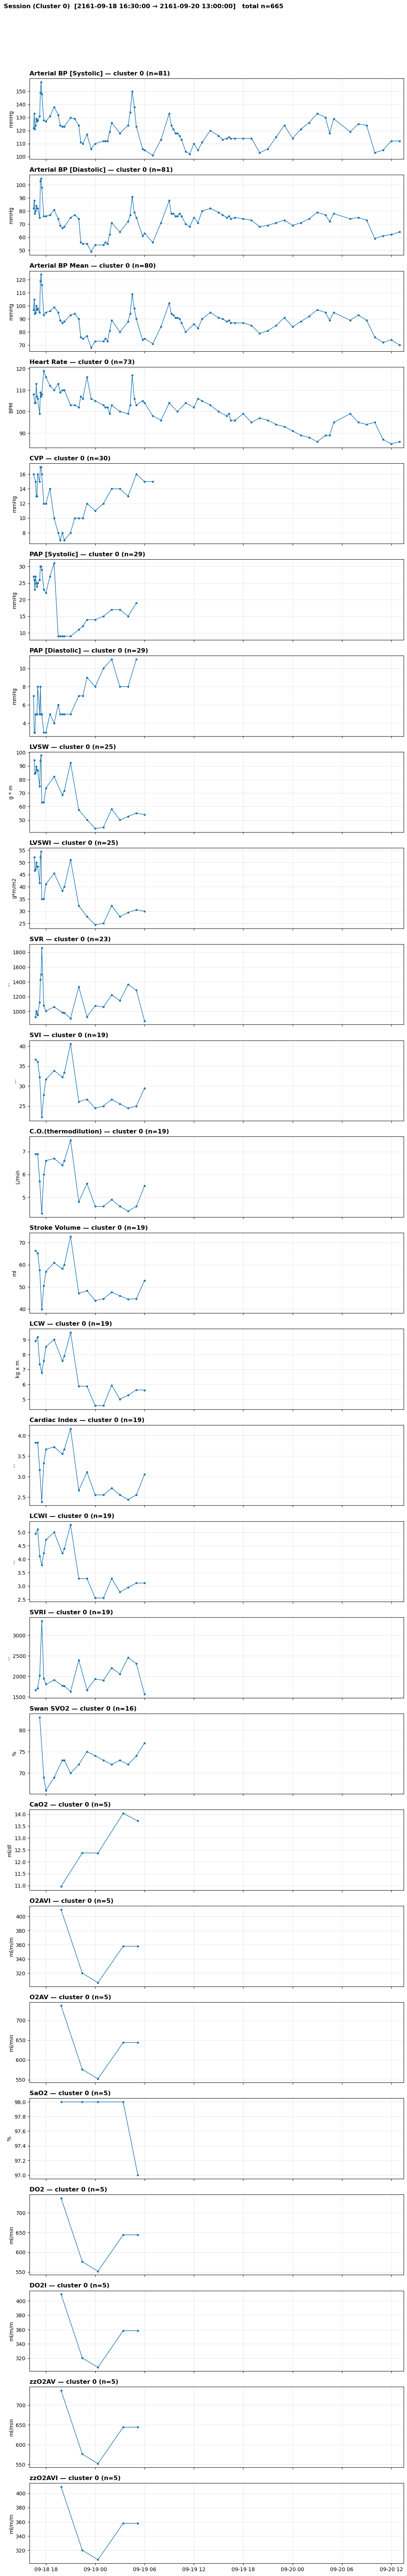

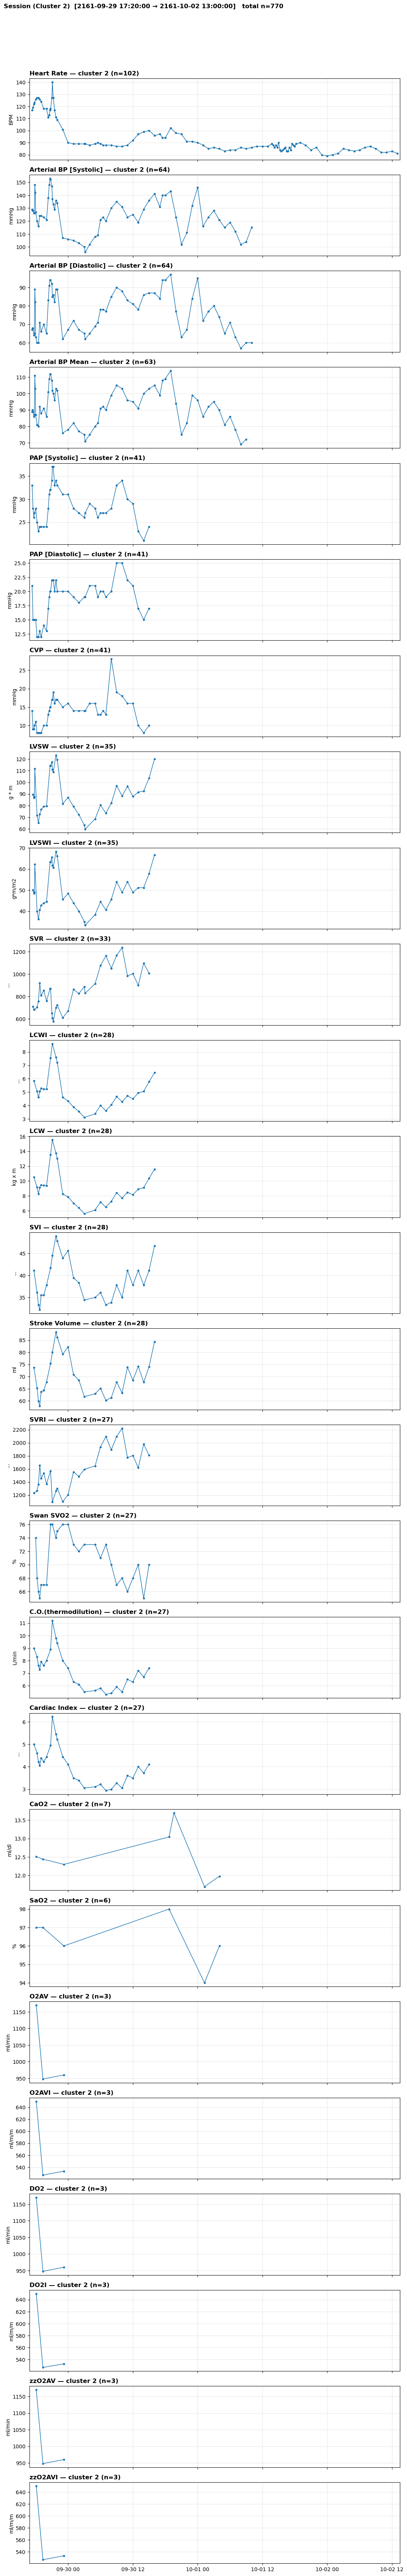

In [ ]:
plot_sessions_by_cluster(
    df_with_clusters, ranges,
    clusters_to_plot=[0, 2],           # pick your two big sessions
    pad_minutes=30                     # small padding so edges aren’t cramped
)

In [ ]:
first_hadm_id

np.int64(100242)

In [31]:
input_event_cv_df =  pd.read_csv('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/input_data/INPUTEVENTS_CV.csv')

input_event_cv_df.columns = input_event_cv_df.columns.str.lower()
input_event_cv_df = input_event_cv_df[treatment_cols_to_keep['inputevents_cv']]
input_event_cv_df.rename(columns={'itemid': 'item_id'}, inplace=True)
input_event_cv_df = attach_item_labels(input_event_cv_df, items_df)
input_event_cv_df.dropna(subset=['hadm_id'], inplace=True)
input_event_cv_df = input_event_cv_df[input_event_cv_df['hadm_id'].isin(hadm_ids)]
input_event_cv_df = (
    input_event_cv_df
    .sort_values(['hadm_id', 'charttime'], ascending=[True, True])
    .set_index('hadm_id', drop=False)
)
input_event_cv_df.head()

/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_84563/701548297.py:1: DtypeWarning: Columns (7,9,17,20,21) have mixed types. Specify dtype option on import or set low_memory=False.
  input_event_cv_df =  pd.read_csv('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/input_data/INPUTEVENTS_CV.csv')


,subject_id,hadm_id,item_id,charttime,amount,amountuom,originalroute,item_label
hadm_id,,,,,,,,
100031.0,6892,100031.0,30102,2140-11-11 22:00:00,2484.0,ml,Intravenous Push,OR Colloid
100031.0,6892,100031.0,30101,2140-11-11 22:00:00,3000.0,ml,Intravenous Push,OR Crystalloid
100031.0,6892,100031.0,30013,2140-11-11 22:00:00,0.0,ml,Intravenous Push,D5W
100031.0,6892,100031.0,30140,2140-11-11 22:00:00,0.0,ml,Intravenous Push,30140
100031.0,6892,100031.0,30013,2140-11-11 22:00:00,0.0,ml,Intravenous Push,D5W


In [32]:
input_event_cv_df.loc[first_hadm_id]

,subject_id,hadm_id,item_id,charttime,amount,amountuom,originalroute,item_label
hadm_id,,,,,,,,
100242.0,18996,100242.0,30101,2161-09-18 17:30:00,3400.0,ml,Intravenous Push,OR Crystalloid
100242.0,18996,100242.0,30140,2161-09-18 17:30:00,0.0,ml,Intravenous Push,30140
100242.0,18996,100242.0,30103,2161-09-18 17:30:00,540.0,ml,Intravenous Push,OR FFP
100242.0,18996,100242.0,30104,2161-09-18 17:30:00,1125.0,ml,Intravenous Push,OR Packed RBC's
100242.0,18996,100242.0,30013,2161-09-18 17:30:00,0.0,ml,Intravenous Push,D5W
...,...,...,...,...,...,...,...,...
100242.0,18996,100242.0,30013,2161-10-02 07:00:00,10.0,ml,Intravenous Push,D5W
100242.0,18996,100242.0,30013,2161-10-02 08:00:00,0.0,ml,Intravenous Push,D5W
100242.0,18996,100242.0,30013,2161-10-02 09:00:00,10.0,ml,Intravenous Push,D5W


In [33]:
import pandas as pd
import numpy as np
from typing import Optional

def build_inputs_df(df: pd.DataFrame) -> pd.DataFrame:
    """
    Clean IV/medication input events and return a tidy dataframe with:
       subject_id, hadm_id, item_id, input_name, input_class,
       start_time, end_time, rate, rate_uom, rate/weight
    Removes cancelled/rejected rows. Sorted by hadm_id, item_id, start_time.
    """
    if df.empty:
        return pd.DataFrame()

    # ---- Column resolver
    lower = {c.lower(): c for c in df.columns}
    def pick(*cands: str) -> Optional[str]:
        for c in cands:
            if c.lower() in lower:
                return lower[c.lower()]
        return None

    col_subject = pick("subject_id", "subjectid")
    col_hadm    = pick("hadm_id", "hadmid")
    col_item    = pick("item_id", "itemid")
    col_name    = pick("ordercategoryname")
    col_class   = pick("ordercategorydescription")
    col_start   = pick("start_time", "starttime", "startdate", "charttime")
    col_end     = pick("end_time", "endtime", "enddate", "stoptime")
    col_rate    = pick("rate")
    col_rate_u  = pick("rate_uom", "rateuom")
    col_weight  = pick("patientweight", "weight", "actualbedweight")

    needed = [col_subject, col_hadm, col_item, col_start, col_end, col_rate]
    if any(c is None for c in needed):
        raise ValueError(f"Missing required columns; found: {needed}")

    # ---- Remove cancelled/rejected
    cancel_cols = [c for c in [
        pick("cancelreason"), pick("iscanceled"), pick("is_canceled"),
        pick("iscancelled"), pick("is_cancelled"), pick("canceled"), pick("cancelled")
    ] if c is not None]
    status_col  = pick("statusdescription", "status", "orderstatus")
    comments_cancel_col = pick("comments_cancelledby", "comments_canceledby")

    keep = pd.Series(True, index=df.index)
    for c in cancel_cols:
        s = df[c]
        keep &= s.isna() | (s == 0) | (s is False) | (s.astype(str).str.strip().isin(["0","False","false"]))
    if status_col is not None:
        keep &= ~df[status_col].astype(str).str.contains(r"cancel|reject|discontinu", case=False, na=False)
    if comments_cancel_col is not None:
        keep &= df[comments_cancel_col].isna()

    dfc = df.loc[keep].copy()

    # ---- Select & normalize
    out_cols = [col_subject, col_hadm, col_item, col_name, col_class, col_start, col_end, col_rate]
    if col_rate_u is not None: out_cols.append(col_rate_u)
    if col_weight is not None: out_cols.append(col_weight)
    out = dfc[out_cols].copy()

    # Convert datetimes
    out[col_start] = pd.to_datetime(out[col_start], errors="coerce", utc=True)
    out[col_end]   = pd.to_datetime(out[col_end], errors="coerce", utc=True)

    # Numeric conversions
    out[col_rate]  = pd.to_numeric(out[col_rate], errors="coerce")
    if col_weight is not None:
        out[col_weight] = pd.to_numeric(out[col_weight], errors="coerce")

    # Compute rate/weight
    if col_weight is not None:
        rw = out[col_rate] / out[col_weight].replace({0: np.nan})
    else:
        rw = np.nan

    # Rename to desired schema
    rename_map = {
        col_subject: "subject_id",
        col_hadm:    "hadm_id",
        col_item:    "item_id",
        col_name:    "input_name",
        col_class:   "input_class",
        col_start:   "start_time",
        col_end:     "end_time",
        col_rate:    "rate",
    }
    if col_rate_u is not None:
        rename_map[col_rate_u] = "rate_uom"
    out = out.rename(columns=rename_map)

    # Ensure rate_uom exists
    if "rate_uom" not in out.columns:
        out["rate_uom"] = pd.NA

    out["rate/weight"] = rw

    # Sort
    out = out.sort_values(["hadm_id", "item_id", "start_time"], kind="mergesort", na_position="last")

    return out[["subject_id","hadm_id","item_id","input_name","input_class",
                "start_time","end_time","rate","rate_uom","rate/weight"]].reset_index(drop=True)

In [34]:
inputevents_mv_df = pd.read_csv('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/input_data/INPUTEVENTS_MV.csv')
inputevents_mv_df = build_inputs_df(inputevents_mv_df)
inputevents_mv_df = attach_item_labels(inputevents_mv_df, items_df)
inputevents_mv_df = inputevents_mv_df[inputevents_mv_df['hadm_id'].isin(hadm_ids)]
inputevents_mv_df = (
    inputevents_mv_df
    .sort_values(['hadm_id', 'start_time'], ascending=[True, True])
    .set_index('hadm_id', drop=False)
)
inputevents_mv_df.head()


,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,rate/weight,item_label
hadm_id,,,,,,,,,,,
100061,11728,100061,220949,01-Drips,Continuous Med,2178-12-25 14:15:00+00:00,2178-12-25 20:30:00+00:00,6.075334,mL/hour,0.075004,Dextrose 5%
100061,11728,100061,221662,01-Drips,Continuous Med,2178-12-25 14:15:00+00:00,2178-12-25 20:30:00+00:00,2.000110,mcg/kg/min,0.024693,Dopamine
100061,11728,100061,225825,02-Fluids (Crystalloids),Continuous IV,2178-12-25 14:15:00+00:00,2178-12-25 16:59:00+00:00,60.000000,mL/hour,0.740741,D5NS
100061,11728,100061,226452,14-Oral/Gastric Intake,Bolus,2178-12-25 18:04:00+00:00,2178-12-25 18:05:00+00:00,NaN,NaN,NaN,PO Intake
100061,11728,100061,220952,05-Med Bolus,Drug Push,2178-12-25 19:30:00+00:00,2178-12-25 19:31:00+00:00,NaN,NaN,NaN,Dextrose 50%


In [35]:
unique_cv_hadm_ids = set(input_event_cv_df['hadm_id'].unique())

# Get the set of unique hadm_ids in MV that are in relevant_patient_ids
unique_mv_hadm_ids = set(inputevents_mv_df['hadm_id'].unique())

# hadm_ids in both cv and mv
both_cv_mv_hadm_ids = unique_cv_hadm_ids & unique_mv_hadm_ids

# hadm_ids in cv but not in mv
cv_only_hadm_ids = unique_cv_hadm_ids - unique_mv_hadm_ids

# hadm_ids in mv but not in cv
mv_only_hadm_ids = unique_mv_hadm_ids - unique_cv_hadm_ids

print(f"Number of hadm_ids in both cv and mv: {len(both_cv_mv_hadm_ids)}")
print(f"Number of hadm_ids in cv but not in mv: {len(cv_only_hadm_ids)}")
print(f"Number of hadm_ids in mv but not in cv: {len(mv_only_hadm_ids)}")

Number of hadm_ids in both cv and mv: 12
Number of hadm_ids in cv but not in mv: 2629
Number of hadm_ids in mv but not in cv: 626


In [36]:
sample_cv_data = input_event_cv_df[input_event_cv_df['hadm_id'] == 100336]
sample_cv_data_dopamine = sample_cv_data[sample_cv_data['item_label'] == 'Dopamine']

sample_cv_data_dopamine.sort_values(by='charttime', ascending=True)[:30]

/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_84563/3169563792.py:4: FutureWarning: The behavior of obj[i:j] with a float-dtype index is deprecated. In a future version, this will be treated as positional instead of label-based. For label-based slicing, use obj.loc[i:j] instead
  sample_cv_data_dopamine.sort_values(by='charttime', ascending=True)[:30]


,subject_id,hadm_id,item_id,charttime,amount,amountuom,originalroute,item_label
hadm_id,,,,,,,,


In [ ]:
sample_mv_data = inputevents_mv_df[inputevents_mv_df['hadm_id'] == 100336].sort_values(by='start_time', ascending=True)
sample_mv_data[sample_mv_data['item_label'] == 'Dopamine'][:40]

,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,rate/weight,item_label
14894,8498,100336,221662,01-Drips,Continuous Med,2144-08-27 00:50:00+00:00,2144-08-27 01:19:00+00:00,5.004629,mcg/kg/min,0.054163,Dopamine
14895,8498,100336,221662,01-Drips,Continuous Med,2144-08-27 01:19:00+00:00,2144-08-27 08:17:00+00:00,10.009259,mcg/kg/min,0.108325,Dopamine


In [23]:
relevant_patient_ids = pd.read_csv('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/processed_data/relevant_patient_ids.csv')

relevant_patient_ids.head()

,HADM_ID,SUBJECT_ID
0,100031,6892
1,100061,11728
2,100098,65411
3,100103,3365
4,100114,1900


In [ ]:
len(relevant_patient_ids)

3268

3250366

In [37]:
len(inputevents_mv_df[inputevents_mv_df['hadm_id'].isin(relevant_patient_ids['HADM_ID'])])

369657

In [38]:
import pandas as pd
from pathlib import Path

def concatenate_patient_waveforms(hadm_id, full_waveform_dir):
    """
    Finds all waveform files for a patient, concatenates them, and sorts by time.

    Args:
        hadm_id (int): The hospital admission ID.
        full_waveform_dir (Path): Directory containing the full waveform Parquet files.

    Returns:
        pd.DataFrame: A single DataFrame containing all waveform data for the patient,
                      sorted chronologically. Returns an empty DataFrame if no files are found.
    """
    waveform_files = list(full_waveform_dir.glob(f"full_waveform_{hadm_id}_*.parquet"))
    if not waveform_files:
        #debug_print(f"No waveform files found for HADM_ID {hadm_id}")
        return pd.DataFrame()

    df_list = [pd.read_parquet(f) for f in waveform_files]
    full_df = pd.concat(df_list, ignore_index=True)

    # Calculate absolute timestamp for each data point
    full_df['absolute_timestamp'] = full_df.apply(
        lambda row: row['record_start_time'] + pd.to_timedelta(row['time_seconds'], unit='s'),
        axis=1
    )
    
    # Sort the final dataframe by the absolute timestamp
    full_df = full_df.sort_values(by='absolute_timestamp').reset_index(drop=True)
    
    print(f"  Concatenated {len(waveform_files)} waveform files for HADM_ID {hadm_id}.")
    return full_df

def group_into_sessions(df, gap_threshold_hours=24):
    """
    Groups a DataFrame of time-series data into sessions based on time gaps.

    Args:
        df (pd.DataFrame): DataFrame with an 'absolute_timestamp' column.
        gap_threshold_hours (int): The number of hours to consider a gap for a new session.

    Returns:
        pd.DataFrame: The input DataFrame with an added 'session_id' column.
    """
    if df.empty:
        return df

    time_diff = df['absolute_timestamp'].diff()
    session_starts = time_diff > pd.Timedelta(hours=gap_threshold_hours)
    df['session_id'] = session_starts.cumsum()
    
    num_sessions = df['session_id'].nunique()
    if num_sessions > 1:
        print(f"  Grouped data into {num_sessions} session(s) based on a {gap_threshold_hours}-hour gap threshold.")
    
    return df



full_waveform_dir = Path('/Users/riccardoconci/Local_documents/Counterfactual_ICU/data/mimic_3_data/processed_data/full_trajectories')
wf_df = concatenate_patient_waveforms(101662, full_waveform_dir)

wf_df = group_into_sessions(wf_df)

wf_df


  Concatenated 6 waveform files for HADM_ID 101662.


,time_seconds,HR,PULSE,ABP,ABP Sys,ABP Dias,ABP Mean,CVP,RESP,ST III,...,ART,ART Sys,ART Dias,ART Mean,NBP,NBP Sys,NBP Dias,NBP Mean,absolute_timestamp,session_id
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-10 09:54:16,0
1,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-10 09:54:26,0
2,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-10 09:54:36,0
3,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-10 09:54:46,0
4,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-10 09:54:56,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77320,1880,96.000000,96.0,NaN,145.0,78.0,103.0,NaN,16.0,0.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-19 19:15:40,0
77321,1890,96.000000,96.0,NaN,145.0,78.0,102.0,NaN,16.0,0.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-19 19:15:50,0
77322,1900,96.000000,96.0,NaN,144.0,77.0,101.0,NaN,16.0,0.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-19 19:16:00,0
77323,1910,95.333333,93.6,NaN,142.0,76.0,100.0,NaN,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-19 19:16:10,0


In [131]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
from typing import Iterable, Optional, Tuple, Sequence, List, Dict

class PanelStack:
    def __init__(
        self,
        *,
        total_rows:int = 400,             # big row budget so we never run out
        figsize: Tuple[float, float] = (12, 6),
        auto_height_per_axis: float = 0.9, # inches per axis (auto-grow)
        min_height: float = 6.0,
        max_height: float = 60.0,
        left:float = 0.08, right:float = 0.98,
        top:float = 0.96, bottom:float = 0.06,
        hspace:float = 0.15,
        title: Optional[str] = None,
    ):
        self.fig = plt.figure(figsize=figsize)
        self.gs_master = self.fig.add_gridspec(
            nrows=total_rows, ncols=1, left=left, right=right,
            top=top, bottom=bottom, hspace=hspace
        )
        self._cursor = 0
        self._share_ax = None
        self._axes: List[plt.Axes] = []
        self._title = title
        self._auto_height_per_axis = auto_height_per_axis
        self._min_height = min_height
        self._max_height = max_height

    def _claim_rows(self, n:int) -> GridSpec:
        if self._cursor + n > self.gs_master.nrows:
            raise RuntimeError("PanelStack ran out of rows; raise total_rows.")
        sub = self.gs_master[self._cursor:self._cursor+n, 0].subgridspec(nrows=n, ncols=1, hspace=0.05)
        self._cursor += n
        return sub

    def _fmt_datetime_axis(self, axes: List[plt.Axes]):
        # Full datetime
        formatter = mdates.DateFormatter('%Y-%m-%d %H:%M', tz=mdates.UTC)
        locator = mdates.AutoDateLocator()
        for ax in axes:
            ax.xaxis.set_major_locator(locator)
            ax.xaxis.set_major_formatter(formatter)
            for t in ax.get_xticklabels():
                t.set_rotation(30); t.set_ha("right")

    # ----------------------------------------------------------
    # Panel 1: Inputs timeline by item label (sorted by class)
    # ----------------------------------------------------------
    def add_inputs_timeline_by_label(
        self,
        df: pd.DataFrame,
        hadm_id: int,
        *,
        bolus_labels: Iterable[str] = ("bolus", "drug push"),
        continuous_labels: Iterable[str] = ("continuous iv", "continuous med"),
        class_order: Sequence[str] = ("continuous", "bolus/push", "other"),
        height_units_per_item:int = 2,
        star_size: int = 120,
        # NEW:
        items_per_page: int = 16,   # how many item labels to show per page
        page: int = 1,              # 1-based page number
        label_max_chars: int = 36,  # truncate very long labels for readability
        keep_labels: Optional[Sequence[str]] = None,  # optionally whitelist a subset
    ):
        req = ["hadm_id","item_id","item_label","input_name","input_class",
            "start_time","end_time","rate","rate_uom"]
        miss = [c for c in req if c not in df.columns]
        if miss:
            raise ValueError(f"inputs dataframe missing columns: {miss}")

        dfi = df.loc[df["hadm_id"] == hadm_id].copy()
        if dfi.empty:
            raise ValueError(f"No rows for hadm_id={hadm_id} in inputs dataframe.")

        dfi["start_time"] = pd.to_datetime(dfi["start_time"], utc=True, errors="coerce")
        dfi["end_time"]   = pd.to_datetime(dfi["end_time"],   utc=True, errors="coerce").fillna(dfi["start_time"])
        dfi["rate"]       = pd.to_numeric(dfi["rate"], errors="coerce")

        ic = dfi["input_class"].astype(str).str.lower()
        iname = dfi["input_name"].astype(str).str.lower()

        bolus_mask = pd.Series(False, index=dfi.index)
        for lbl in bolus_labels:
            bolus_mask |= ic.str.contains(lbl, na=False) | iname.str.contains(lbl, na=False)

        cont_mask = pd.Series(False, index=dfi.index)
        for lbl in continuous_labels:
            cont_mask |= ic.str.contains(lbl, na=False) | iname.str.contains(lbl, na=False)

        dfi["row_class"] = np.where(cont_mask, "continuous",
                            np.where(bolus_mask, "bolus/push", "other"))
        priority = {c:i for i,c in enumerate(class_order)}

        # ---- pick a single class per item_label without the FutureWarning
        def choose_class(s: pd.Series) -> str:
            vc = s.value_counts()
            # tie-break by class_order priority
            return min(vc.index, key=lambda c: (priority.get(c, 999), -vc[c]))
        label_class = (dfi.groupby("item_label", sort=False)["row_class"]
                        .agg(choose_class)
                        .rename("label_class"))
        dfi = dfi.merge(label_class, left_on="item_label", right_index=True, how="left")

        # ---- build label order (by class, then alpha)
        all_labels = (
            dfi[["item_label","label_class"]].drop_duplicates()
            .sort_values(["label_class","item_label"],
                            key=lambda s: s.map(priority) if s.name=="label_class"
                                        else s.str.lower())
            ["item_label"].tolist()
        )

        # Optional filtering
        if keep_labels is not None:
            keep_set = set(keep_labels)
            all_labels = [lab for lab in all_labels if lab in keep_set]

        # ---- paginate
        if items_per_page is not None and items_per_page > 0:
            start = max(0, (page - 1) * items_per_page)
            end   = start + items_per_page
            labels = all_labels[start:end]
        else:
            labels = all_labels

        if not labels:
            raise ValueError("No labels to display after filtering/pagination.")

        # allocate rows
        n_items = len(labels)
        sub = self._claim_rows(n_items * height_units_per_item)
        axes_local: List[plt.Axes] = []

        for i, label in enumerate(labels):
            r0 = i * height_units_per_item
            ax = self.fig.add_subplot(sub[r0, 0], sharex=self._share_ax)
            if self._share_ax is None:
                self._share_ax = ax
            axes_local.append(ax)

            g = dfi[dfi["item_label"] == label]
            g_bolus = g[g["row_class"] == "bolus/push"]
            g_cont  = g[g["row_class"] == "continuous"]
            g_oth   = g[g["row_class"] == "other"]

            # y scale
            all_rates = pd.concat([g_bolus["rate"], g_cont["rate"], g_oth["rate"]], axis=0)
            ymax = float(all_rates.max()) if all_rates.notna().any() else 1.0
            if not np.isfinite(ymax) or ymax <= 0: ymax = 1.0
            ax.set_ylim(0, ymax * 1.15)

            # draw continuous
            for _, r in g_cont.iterrows():
                if pd.notna(r["rate"]):
                    ax.hlines(y=r["rate"], xmin=r["start_time"], xmax=r["end_time"], linewidth=3)
                else:
                    ax.axvspan(r["start_time"], r["end_time"], alpha=0.25)

            # draw bolus/push
            if not g_bolus.empty:
                y_star = g_bolus["rate"].fillna(0.0)
                ax.scatter(g_bolus["start_time"], y_star, marker="*", s=star_size, zorder=3)

            # draw others
            for _, r in g_oth.iterrows():
                if r["start_time"] == r["end_time"]:
                    ax.scatter([r["start_time"]], [r["rate"] if pd.notna(r["rate"]) else 0.0],
                            marker="*", s=star_size/1.5, zorder=3)
                else:
                    if pd.notna(r["rate"]):
                        ax.hlines(y=r["rate"], xmin=r["start_time"], xmax=r["end_time"], linewidth=2, linestyle="--")
                    else:
                        ax.axvspan(r["start_time"], r["end_time"], alpha=0.15, hatch="///")

            # tidy labels
            unit_vals = g["rate_uom"].dropna().astype(str).unique()
            unit = unit_vals[0] if len(unit_vals) == 1 else ""
            short = (label[:label_max_chars] + "…") if len(label) > label_max_chars else label
            ax.set_ylabel(f"{short}\n{unit}".strip(), rotation=0, ha="right", va="center", labelpad=30)
            ax.tick_params(axis='y', labelsize=8)
            ax.grid(True, axis="y", linestyle=":", alpha=0.5)

        # x-limits for this block
        x_min = min(dfi["start_time"].dropna().min(), dfi["end_time"].dropna().min())
        x_max = max(dfi["start_time"].dropna().max(), dfi["end_time"].dropna().max())
        axes_local[-1].set_xlim(x_min, x_max)

        # legend
        axes_local[0].plot([], [], linewidth=3, label="Continuous (rate)")
        axes_local[0].fill_between([], [], [], alpha=0.25, label="Continuous (no rate)")
        axes_local[0].scatter([], [], marker="*", s=star_size, label="Bolus / Push")
        axes_local[0].legend(loc="upper right", frameon=False)

        self._axes.extend(axes_local)
        return axes_local, {"all_labels": all_labels, "shown": labels}

    # ----------------------------------------------------------
    # Panel 2: Waveforms / vitals (clean + smooth)
    # ----------------------------------------------------------
    @staticmethod
    def _clean_and_smooth(df: pd.DataFrame, signals: List[str], neighbors:int) -> pd.DataFrame:
        out = pd.DataFrame(index=df.index, columns=signals, dtype=float)
        win_len = 2*neighbors + 1
        kernel = np.ones(win_len, dtype=float)

        for sig in signals:
            s = df[sig].astype(float).copy()

            if sig.lower() == 'cvp':
                s[s > 50] = np.nan
            else:
                med = np.nanmedian(s)
                sd  = np.nanstd(s, ddof=1)
                if np.isfinite(sd) and sd > 0:
                    s[np.abs(s - med) > (3*sd)] = np.nan

            vals  = s.to_numpy(dtype=float)
            num   = np.convolve(np.nan_to_num(vals, nan=0.0), kernel, mode='same')
            valid = np.isfinite(vals).astype(float)
            den   = np.convolve(valid, kernel, mode='same')

            out_arr = np.empty_like(num, dtype=float)
            np.divide(num, den, out=out_arr, where=den > 0)
            out_arr[den == 0] = np.nan

            out[sig] = out_arr
        return out

    def add_waveforms(
        self,
        full_waveform_df: pd.DataFrame,
        signals: List[str] = ('HR','ABP Mean','CVP','RESP','SpO2'),
        *,
        neighbors:int = 3,
        height_units_per_signal:int = 2,
        seconds_col: str = 'time_seconds',
        base_time_candidates = ('record_start_time','t0_timestamps'),
        abs_time_col: str = 'absolute_timestamp',
    ):
        # ensure absolute time present (or build it)
        if abs_time_col not in full_waveform_df.columns:
            wf = add_abs_time(full_waveform_df, seconds_col=seconds_col,
                            base_time_candidates=base_time_candidates, out_col=abs_time_col)
        else:
            wf = full_waveform_df.copy()

        keep = [s for s in signals if s in wf.columns]
        if not keep:
            raise ValueError("None of the requested signals are present in the waveform dataframe.")

        # clean + smooth (same logic as before)
        sm = self._clean_and_smooth(wf[keep], keep, neighbors)
        # align index to absolute datetime
        sm.index = pd.to_datetime(wf[abs_time_col], utc=True, errors='coerce')

        # allocate rows (one axis per signal)
        sub = self._claim_rows(len(keep) * height_units_per_signal)
        axes_local: List[plt.Axes] = []
        for i, sig in enumerate(keep):
            r0 = i*height_units_per_signal
            ax = self.fig.add_subplot(sub[r0, 0], sharex=self._share_ax)
            if self._share_ax is None:
                self._share_ax = ax
            axes_local.append(ax)

            y = sm[sig]
            if np.isfinite(y).any():
                ax.plot(y.index, y.to_numpy(), linewidth=1.5, label=sig)
            ax.set_ylabel(sig)
            ax.grid(True)
            ax.legend(loc='upper right')

        self._axes.extend(axes_local)
        return axes_local
    
    def add_action_cluster_lines(
        self,
        df: pd.DataFrame,
        hadm_id: int,
        *,
        time_col: str = "start_time",
        cluster_col: str = "action_cluster_id",
        trigger_col: str = "trigger",
        include_singletons: bool = False,   # draw clusters of size==1 if you created them
        palette_name: str = "tab20",
        alpha: float = 0.35,
        linewidth: float = 1.8,
        zorder: int = 1,                    # slightly behind markers/lines you draw later
        show_legend: bool = True,
        max_legend_items: int = 12,
    ):
        """
        Draw vertical lines at each (triggered) event that belongs to an action cluster,
        colored by the cluster index for this hadm_id. Lines are drawn on ALL axes
        already added to the PanelStack (inputs + waveforms).
        """
        if not self._axes:
            return []  # nothing to draw on yet

        # slice to this encounter
        cols_needed = {time_col, cluster_col, trigger_col, "hadm_id"}
        missing = cols_needed - set(df.columns)
        if missing:
            raise ValueError(f"Missing required columns for cluster lines: {sorted(missing)}")

        dfe = df.loc[df["hadm_id"] == hadm_id].copy()
        if dfe.empty:
            return []

        # keep trigger events; optionally skip singletons
        dfe[time_col] = pd.to_datetime(dfe[time_col], utc=True, errors="coerce")
        mask = dfe[trigger_col] & dfe[cluster_col].notna()
        if not include_singletons and "action_cluster_size" in dfe.columns:
            mask &= (dfe["action_cluster_size"] >= 2)
        events = dfe.loc[mask, [time_col, cluster_col]].dropna()
        if events.empty:
            return []

        # stable color per cluster index (1..N)
        clusters = sorted(events[cluster_col].dropna().astype(int).unique())
        import matplotlib as mpl
        cmap = mpl.cm.get_cmap(palette_name, max(3, len(clusters)))
        color_map = {cid: cmap((cid - 1) % cmap.N) for cid in clusters}

        # sort by time for neat legend ordering
        events = events.sort_values(time_col)

        # draw on every axis we’ve created so far
        handles = {}
        for ax in self._axes:
            for _, r in events.iterrows():
                cid = int(r[cluster_col])
                color = color_map[cid]
                ax.axvline(r[time_col], color=color, alpha=alpha, linewidth=linewidth, zorder=zorder)
                # one legend handle per cluster id
                if cid not in handles:
                    handles[cid] = mpl.lines.Line2D([], [], color=color, alpha=alpha,
                                                    linewidth=linewidth, label=f"cluster {cid}")

        # optional legend on the top-most axis
        if show_legend and handles:
            first_ax = self._axes[0]
            # limit the legend so it doesn’t get unwieldy
            items = [handles[cid] for cid in sorted(handles)[:max_legend_items]]
            first_ax.legend(handles=items, loc="lower left", frameon=False, title="Action clusters")

        return list(sorted(color_map.items()))

    # ----------------------------------------------------------
    # Finalize: set x formatter once at the end
    # ----------------------------------------------------------
    def finalize(self, xlabel: str = "Time (UTC)"):
        if not self._axes:
            return self.fig, []
        # datetime ticks everywhere
        self._fmt_datetime_axis(self._axes)
        self._axes[-1].set_xlabel(xlabel)
        if self._title:
            self.fig.suptitle(self._title, y=0.995, fontsize=12)
        # ---- auto height based on number of axes
        if self._auto_height_per_axis and self._auto_height_per_axis > 0:
            n_ax = len(self._axes)
            w, _ = self.fig.get_size_inches()
            h = min(self._max_height, max(self._min_height, n_ax * self._auto_height_per_axis))
            self.fig.set_size_inches(w, h, forward=True)
        return self.fig, self._axes

  Concatenated 6 waveform files for HADM_ID 101662.


,time_seconds,HR,PULSE,ABP,ABP Sys,ABP Dias,ABP Mean,CVP,RESP,ST III,...,ART,ART Sys,ART Dias,ART Mean,NBP,NBP Sys,NBP Dias,NBP Mean,absolute_timestamp,session_id
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-10 09:54:16,0
1,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-10 09:54:26,0
2,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-10 09:54:36,0
3,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-10 09:54:46,0
4,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-10 09:54:56,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
77320,1880,96.000000,96.0,NaN,145.0,78.0,103.0,NaN,16.0,0.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-19 19:15:40,0
77321,1890,96.000000,96.0,NaN,145.0,78.0,102.0,NaN,16.0,0.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-19 19:15:50,0
77322,1900,96.000000,96.0,NaN,144.0,77.0,101.0,NaN,16.0,0.4,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-19 19:16:00,0
77323,1910,95.333333,93.6,NaN,142.0,76.0,100.0,NaN,15.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2104-06-19 19:16:10,0


,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,rate/weight,item_label
2,58526,100001,221828,05-Med Bolus,Drug Push,2117-09-12 15:24:00+00:00,2117-09-12 15:25:00+00:00,NaN,NaN,NaN,Hydralazine
37,58526,100001,225153,05-Med Bolus,Drug Push,2117-09-13 16:30:00+00:00,2117-09-13 16:31:00+00:00,NaN,NaN,NaN,Labetalol
38,58526,100001,225158,01-Drips,Continuous Med,2117-09-11 12:50:00+00:00,2117-09-11 12:55:00+00:00,5.000000,mL/hour,0.050505,NaCl 0.9%
39,58526,100001,225158,01-Drips,Continuous Med,2117-09-11 12:55:00+00:00,2117-09-11 14:00:00+00:00,6.996487,mL/hour,0.070672,NaCl 0.9%
40,58526,100001,225158,02-Fluids (Crystalloids),Continuous IV,2117-09-11 13:48:00+00:00,2117-09-11 15:48:00+00:00,499.999980,mL/hour,5.050505,NaCl 0.9%
...,...,...,...,...,...,...,...,...,...,...,...
3250299,55617,199984,225158,03-IV Fluid Bolus,Bolus,2191-06-10 14:15:00+00:00,2191-06-10 14:16:00+00:00,NaN,NaN,NaN,NaCl 0.9%
3250300,55617,199984,225158,02-Fluids (Crystalloids),Continuous IV,2191-06-10 14:45:00+00:00,2191-06-10 17:00:00+00:00,10.000000,mL/hour,0.163399,NaCl 0.9%
3250317,94911,199992,221662,01-Drips,Continuous Med,2155-02-11 17:45:00+00:00,2155-02-11 19:53:00+00:00,2.000170,mcg/kg/min,0.037456,Dopamine
3250318,94911,199992,221662,01-Drips,Continuous Med,2155-02-11 19:53:00+00:00,2155-02-11 20:36:00+00:00,1.500024,mcg/kg/min,0.028090,Dopamine


In [39]:
import pandas as pd
import numpy as np

def compute_triggers(
    df: pd.DataFrame,
    relative_change: float = 0.30,   # ≥30% up or down = substantial
    abs_min_change: float = 0.02,    # ignore tiny jitter
    nacl_high_rate: float = 250.0,   # mL/h considered "much higher" for NaCl 0.9%
    nacl_jump_abs: float = 200.0,    # absolute jump for NaCl to count
    throttle: bool = False,          # << no throttling by default per your new request
    window_max_trig: int = 2,        # (only used if throttle=True)
    window_minutes: int = 10         # (only used if throttle=True)
) -> pd.DataFrame:
    df = df.copy()

    # Ensure times are datetimes
    for c in ("start_time", "end_time"):
        if c in df.columns:
            df[c] = pd.to_datetime(df[c], errors="coerce")

    # Normalize to a single numeric "rate_norm"
    has_rate_weight = "rate/weight" in df.columns
    df["rate_weight_norm"] = df["rate/weight"] if has_rate_weight else np.nan
    df["rate_norm"] = df["rate_weight_norm"].where(~df["rate_weight_norm"].isna(), df["rate"])

    # Mark pushes/boluses as pulses with value=1 at start if they don't have a rate
    is_bolus = df["input_class"].str.contains("bolus|push", case=False, na=False) if "input_class" in df.columns else pd.Series(False, index=df.index)
    df.loc[is_bolus & df["rate_norm"].isna(), "rate_norm"] = 1.0

    df["rate_norm"] = df["rate_norm"].fillna(0.0)

    # Group by patient-encounter and medication name
    group_keys = ["subject_id", "hadm_id", "item_label"]
    df = df.sort_values(group_keys + ["start_time"]).copy()

    # Previous rate within group
    df["prev_rate"] = df.groupby(group_keys)["rate_norm"].shift(1)

    # First administration (0 -> >0)
    first_admin = (df["prev_rate"].fillna(0) == 0) & (df["rate_norm"] > 0)

    # Significant titrations
    delta = df["rate_norm"] - df["prev_rate"].fillna(0)
    abs_delta = delta.abs()
    with np.errstate(divide="ignore", invalid="ignore"):
        rel_delta = (abs_delta / df["prev_rate"]).replace([np.inf, -np.inf], np.nan).fillna(1.0)

    significant_increase = (delta > 0) & (rel_delta >= relative_change) & (abs_delta >= abs_min_change)
    significant_decrease = (delta < 0) & (rel_delta >= relative_change) & (abs_min_change <= abs_delta)

    # NaCl special case (simple alias set)
    nacl_labels = {"nacl 0.9%", "ns", "normal saline"}
    is_nacl = df["item_label"].astype(str).str.strip().str.lower().isin(nacl_labels)
    nacl_high = (df["rate_norm"] >= nacl_high_rate) & (
        (df["prev_rate"].fillna(0) < nacl_high_rate) | (abs_delta >= nacl_jump_abs)
    )

    # Explicit fluid boluses always trigger
    is_fluid_bolus_row = df["input_name"].str.contains("bolus", case=False, na=False) if "input_name" in df.columns else pd.Series(False, index=df.index)
    fluid_bolus_trigger = is_fluid_bolus_row

    base_trigger = first_admin | significant_increase | significant_decrease | fluid_bolus_trigger

    # For NaCl rows, only trigger for "high rate" or explicit bolus
    trigger = base_trigger.copy()
    trigger.loc[is_nacl] = nacl_high.loc[is_nacl] | fluid_bolus_trigger.loc[is_nacl]

    # Reasons
    reasons = np.where(first_admin, "start", "")
    reasons = np.where(significant_increase & (reasons==""), "increase", reasons)
    reasons = np.where(significant_decrease & (reasons==""), "decrease", reasons)
    reasons = np.where(fluid_bolus_trigger & (reasons==""), "bolus", reasons)
    reasons = np.where(is_nacl & nacl_high, "NaCl_high_rate", reasons)
    reasons = np.where(trigger & (reasons==""), "trigger", reasons)

    df["trigger"] = trigger
    df["trigger_reason"] = reasons

    # Optional throttle (off by default now)
    if throttle:
        def throttle_group(g):
            g2 = g.sort_values("start_time").copy()
            roll = (
                g2.set_index("start_time")["trigger"].astype(int)
                .rolling(f"{window_minutes}min")
                .sum()
            )
            keep = roll <= window_max_trig
            kept = g2["trigger"].copy()
            kept.loc[keep.index] = g2.loc[keep.index, "trigger"] & keep.values
            return kept.sort_index()

        throttled = df.groupby(group_keys, group_keys=False).apply(throttle_group)
        throttled = throttled.astype(bool).reindex(df.index)
        df["trigger_reason"] = np.where(df["trigger"] & (~throttled), "throttled_rolling_window", df["trigger_reason"])
        df["trigger"] = throttled.values

    return df


def _encounter_keys(df: pd.DataFrame):
    # Prefer (subject_id, hadm_id) if available; otherwise fall back to hadm_id only.
    keys = []
    if "subject_id" in df.columns: keys.append("subject_id")
    if "hadm_id" in df.columns: keys.append("hadm_id")
    if not keys:
        raise KeyError("Neither 'subject_id' nor 'hadm_id' found in columns.")
    return keys

def compute_action_clusters(
    df_with_triggers: pd.DataFrame,
    window_minutes: int = 15,
    min_events_in_cluster: int = 2
) -> pd.DataFrame:
    """
    Build action clusters WITHIN an encounter (per hadm_id, and subject_id if present),
    scanning triggers across ALL meds. A cluster starts at a trigger, includes subsequent
    triggers up to (start + window_minutes), then the next cluster starts at the first
    trigger strictly after that window.
    """
    df = df_with_triggers.copy()
    df["action_cluster_id"] = np.nan
    df["action_cluster_size"] = np.nan
    df["action_cluster_rank"] = np.nan  # 1..N within cluster

    enc_keys = _encounter_keys(df)

    def cluster_one_enc(g):
        g = g.sort_values("start_time").copy()
        trig_idx = g.index[g["trigger"]].tolist()
        if not trig_idx:
            return g

        cluster_id = 0
        i = 0
        while i < len(trig_idx):
            start_idx = trig_idx[i]
            t0 = g.loc[start_idx, "start_time"]
            window_end = t0 + pd.Timedelta(minutes=window_minutes)

            # collect all triggers within the window [t0, window_end]
            members = [start_idx]
            j = i + 1
            while j < len(trig_idx) and g.loc[trig_idx[j], "start_time"] <= window_end:
                members.append(trig_idx[j])
                j += 1

            if len(members) >= min_events_in_cluster:
                cluster_id += 1
                size = len(members)
                for rank, idx in enumerate(members, start=1):
                    g.at[idx, "action_cluster_id"] = cluster_id
                    g.at[idx, "action_cluster_size"] = size
                    g.at[idx, "action_cluster_rank"] = rank

                # jump to first trigger AFTER the window
                i = j
            else:
                i += 1

        return g

    df = df.groupby(enc_keys, group_keys=False).apply(cluster_one_enc)
    return df

In [41]:
inputevents_mv_df

,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,rate/weight,item_label
hadm_id,,,,,,,,,,,
100061,11728,100061,220949,01-Drips,Continuous Med,2178-12-25 14:15:00+00:00,2178-12-25 20:30:00+00:00,6.075334,mL/hour,0.075004,Dextrose 5%
100061,11728,100061,221662,01-Drips,Continuous Med,2178-12-25 14:15:00+00:00,2178-12-25 20:30:00+00:00,2.000110,mcg/kg/min,0.024693,Dopamine
100061,11728,100061,225825,02-Fluids (Crystalloids),Continuous IV,2178-12-25 14:15:00+00:00,2178-12-25 16:59:00+00:00,60.000000,mL/hour,0.740741,D5NS
100061,11728,100061,226452,14-Oral/Gastric Intake,Bolus,2178-12-25 18:04:00+00:00,2178-12-25 18:05:00+00:00,NaN,NaN,NaN,PO Intake
100061,11728,100061,220952,05-Med Bolus,Drug Push,2178-12-25 19:30:00+00:00,2178-12-25 19:31:00+00:00,NaN,NaN,NaN,Dextrose 50%
...,...,...,...,...,...,...,...,...,...,...,...
199751,84020,199751,225166,02-Fluids (Crystalloids),Continuous IV,2132-01-23 14:30:00+00:00,2132-01-23 15:30:00+00:00,NaN,NaN,NaN,Potassium Chloride
199751,84020,199751,227522,02-Fluids (Crystalloids),Continuous IV,2132-01-23 14:30:00+00:00,2132-01-23 15:30:00+00:00,49.999999,mL/hour,0.601685,KCL (Bolus)
199751,84020,199751,223258,06-Insulin (Non IV),Drug Push,2132-01-23 15:19:00+00:00,2132-01-23 15:20:00+00:00,NaN,NaN,NaN,Insulin - Regular


In [42]:
input_events_filtered_trigger_meds = compute_triggers(inputevents_mv_df)
input_events_filtered_trigger_meds

ValueError: 'hadm_id' is both an index level and a column label, which is ambiguous.

In [142]:
res = compute_triggers(input_events_filtered_trigger_meds, throttle=False)

# 2) Cluster per encounter (hadm_id / subject_id)
res = res.sort_values(["hadm_id","start_time"] if "subject_id" not in res.columns else ["subject_id","hadm_id","start_time"])
res = compute_action_clusters(res, window_minutes=20, min_events_in_cluster=1)

# Optional: per-encounter summary
enc_keys = ["hadm_id"] if "subject_id" not in res.columns else ["subject_id","hadm_id"]
per_hadm = (
    res.assign(in_cluster=res["action_cluster_id"].notna())
       .groupby(enc_keys, as_index=False)
       .agg(total_rows=("item_label","size"),
            total_triggers=("trigger","sum"),
            rows_in_clusters=("in_cluster","sum"),
            unique_clusters=("action_cluster_id", lambda s: s.dropna().nunique()))
)

/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_65052/1866581255.py:163: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df = df.groupby(enc_keys, group_keys=False).apply(cluster_one_enc)


Saved CSV: /Users/riccardoconci/Local_documents/Counterfactual_ICU/src/data_processing/outputs/cluster_intervals_minutes.csv
Saved histogram: /Users/riccardoconci/Local_documents/Counterfactual_ICU/src/data_processing/outputs/cluster_intervals_hist.png
Saved ECDF: /Users/riccardoconci/Local_documents/Counterfactual_ICU/src/data_processing/outputs/cluster_intervals_ecdf.png


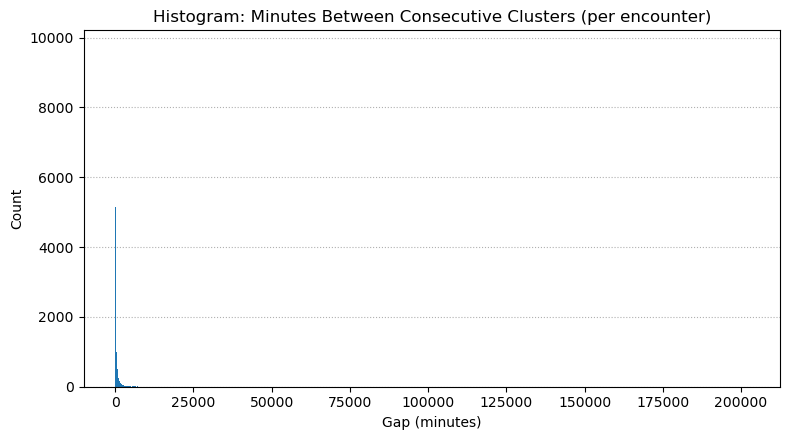

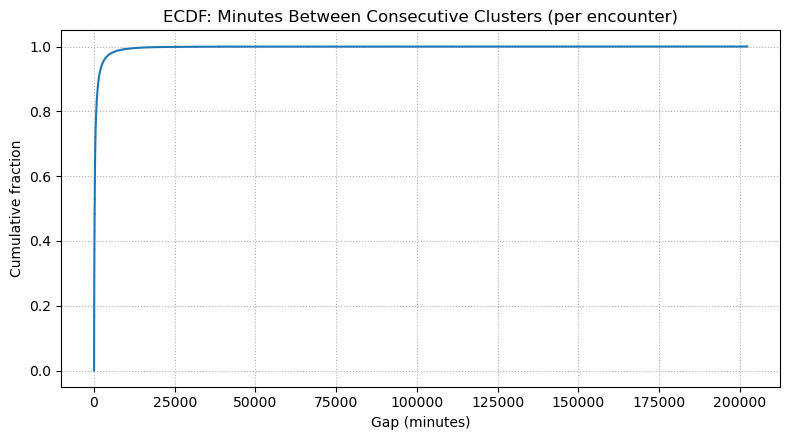

In [144]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

def _encounter_keys(df: pd.DataFrame):
    ks = []
    if "subject_id" in df.columns: ks.append("subject_id")
    if "hadm_id" in df.columns: ks.append("hadm_id")
    if not ks:
        raise KeyError("Need 'hadm_id' (and optional 'subject_id') in `res`.")
    return ks

# ---- assumes `res` already has action_cluster_id + start_time ----
df = res.copy()
df["start_time"] = pd.to_datetime(df["start_time"], utc=True, errors="coerce")
enc_keys = _encounter_keys(df)

# First timestamp (start) for each cluster within an encounter
clustered = df[df["action_cluster_id"].notna()].copy()
clust_times = (
    clustered.groupby(enc_keys + ["action_cluster_id"], as_index=False)["start_time"]
             .min()
             .rename(columns={"start_time": "cluster_start"})
).sort_values(enc_keys + ["cluster_start"])

# Gaps (minutes) between consecutive clusters within same encounter
clust_times["prev_cluster_start"] = clust_times.groupby(enc_keys)["cluster_start"].shift(1)
clust_times["gap_minutes"] = (
    (clust_times["cluster_start"] - clust_times["prev_cluster_start"])
    .dt.total_seconds() / 60.0
)
gaps = clust_times.dropna(subset=["gap_minutes"]).copy()

# ---------- SAVE ARTIFACTS (create folder if needed) ----------
outdir = Path.cwd() / "outputs"
outdir.mkdir(parents=True, exist_ok=True)

gap_csv = outdir / "cluster_intervals_minutes.csv"
cols_out = enc_keys + ["action_cluster_id","prev_cluster_start","cluster_start","gap_minutes"]
gaps[cols_out].to_csv(gap_csv, index=False)
print("Saved CSV:", gap_csv)

# ---------- QUANTILES TABLE ----------
quantiles = [0.05, 0.10, 0.25, 0.5, 0.75, 0.90, 0.95]
q = gaps["gap_minutes"].quantile(quantiles)
summary = pd.DataFrame({
    "quantile": [f"{int(p*100)}%" for p in quantiles],
    "gap_minutes": [float(q.loc[p]) for p in quantiles],
    "n_gaps": [len(gaps)] * len(quantiles),
})
summary

# ---------- HISTOGRAM ----------
plt.figure(figsize=(8, 4.5))
plt.hist(gaps["gap_minutes"].to_numpy(), bins="auto")
plt.title("Histogram: Minutes Between Consecutive Clusters (per encounter)")
plt.xlabel("Gap (minutes)")
plt.ylabel("Count")
plt.grid(True, axis="y", linestyle=":")
hist_png = outdir / "cluster_intervals_hist.png"
plt.tight_layout(); plt.savefig(hist_png, dpi=160)
print("Saved histogram:", hist_png)

# ---------- ECDF ----------
x = np.sort(gaps["gap_minutes"].to_numpy())
y = np.arange(1, len(x)+1) / len(x) if len(x) else np.array([])
plt.figure(figsize=(8, 4.5))
if len(x):
    plt.plot(x, y, drawstyle="steps-post")
plt.title("ECDF: Minutes Between Consecutive Clusters (per encounter)")
plt.xlabel("Gap (minutes)")
plt.ylabel("Cumulative fraction")
plt.grid(True, linestyle=":")
ecdf_png = outdir / "cluster_intervals_ecdf.png"
plt.tight_layout(); plt.savefig(ecdf_png, dpi=160)
print("Saved ECDF:", ecdf_png)

In [145]:
min(gaps[gaps['hadm_id']==101662]['gap_minutes'])

21.0

In [146]:
summary

,quantile,gap_minutes,n_gaps
0,5%,30.0,100163
1,10%,40.0,100163
2,25%,75.0,100163
3,50%,210.0,100163
4,75%,516.0,100163
5,90%,1455.0,100163
6,95%,2734.9,100163


In [133]:
per_hadm[per_hadm['hadm_id']==101662]

,subject_id,hadm_id,total_rows,total_triggers,rows_in_clusters,unique_clusters
15146,81475,101662,649,89,89,79


In [147]:
hadm_id = 101662

res_sample = res[res['hadm_id']==hadm_id]
res_sample

,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,rate/weight,item_label,rate_weight_norm,rate_norm,prev_rate,trigger,trigger_reason,action_cluster_id,action_cluster_size,action_cluster_rank
59657,81475,101662,222056,01-Drips,Continuous Med,2104-06-03 05:35:00+00:00,2104-06-03 06:17:00+00:00,0.500006,mcg/kg/min,0.005453,Nitroglycerin,0.005453,0.005453,NaN,True,start,1.0,1.0,1.0
59658,81475,101662,222056,01-Drips,Continuous Med,2104-06-03 06:17:00+00:00,2104-06-03 06:58:00+00:00,1.000479,mcg/kg/min,0.010910,Nitroglycerin,0.010910,0.010910,0.005453,False,,NaN,NaN,NaN
59659,81475,101662,222056,01-Drips,Continuous Med,2104-06-03 06:58:00+00:00,2104-06-03 09:57:00+00:00,1.401216,mcg/kg/min,0.015280,Nitroglycerin,0.015280,0.015280,0.010910,False,,NaN,NaN,NaN
59660,81475,101662,222056,01-Drips,Continuous Med,2104-06-03 12:59:00+00:00,2104-06-03 14:00:00+00:00,1.401216,mcg/kg/min,0.015280,Nitroglycerin,0.015280,0.015280,0.015280,False,,NaN,NaN,NaN
59661,81475,101662,222056,01-Drips,Continuous Med,2104-06-03 14:00:00+00:00,2104-06-03 15:47:00+00:00,2.001140,mcg/kg/min,0.021823,Nitroglycerin,0.021823,0.021823,0.015280,False,,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60229,81475,101662,225158,02-Fluids (Crystalloids),Continuous IV,2104-06-19 06:00:00+00:00,2104-06-19 06:04:00+00:00,3000.000000,mL/hour,32.715376,NaCl 0.9%,32.715376,32.715376,32.715376,False,,NaN,NaN,NaN
60230,81475,101662,225158,02-Fluids (Crystalloids),Continuous IV,2104-06-19 06:25:00+00:00,2104-06-19 06:29:00+00:00,3000.000000,mL/hour,32.715376,NaCl 0.9%,32.715376,32.715376,32.715376,False,,NaN,NaN,NaN
60231,81475,101662,225158,02-Fluids (Crystalloids),Continuous IV,2104-06-19 06:45:00+00:00,2104-06-19 06:49:00+00:00,3000.000000,mL/hour,32.715376,NaCl 0.9%,32.715376,32.715376,32.715376,False,,NaN,NaN,NaN
60232,81475,101662,225158,01-Drips,Continuous Med,2104-06-19 07:01:00+00:00,2104-06-19 07:52:00+00:00,79.904802,mL/hour,0.871372,NaCl 0.9%,0.871372,0.871372,32.715376,False,decrease,NaN,NaN,NaN


In [ ]:
res_sample["start_time"] = pd.to_datetime(res_sample["start_time"], utc=True, errors="coerce")
res_sample["end_time"] = pd.to_datetime(res_sample["end_time"], utc=True, errors="coerce")
wf_df["absolute_timestamp"] = pd.to_datetime(wf_df["absolute_timestamp"], utc=True, errors="coerce")

t0 = wf_df["absolute_timestamp"].iloc[0]
t1 = wf_df["absolute_timestamp"].iloc[-1]

print("Waveform start:", t0)
print("Waveform end:", t1)

mask = (res_sample["start_time"] > t0) & (res_sample["end_time"] < t1)
res_sample_waveform_filtered = res_sample.loc[mask].copy()


Waveform start: 2104-06-10 09:54:16+00:00
Waveform end: 2104-06-19 19:16:20+00:00


/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_65052/2847396411.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_sample["start_time"] = pd.to_datetime(res_sample["start_time"], utc=True, errors="coerce")
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_65052/2847396411.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  res_sample["end_time"] = pd.to_datetime(res_sample["end_time"], utc=True, errors="coerce")


In [157]:
res_sample_waveform_filtered.columns

Index(['subject_id', 'hadm_id', 'item_id', 'input_name', 'input_class',
       'start_time', 'end_time', 'rate', 'rate_uom', 'rate/weight',
       'item_label', 'rate_weight_norm', 'rate_norm', 'prev_rate', 'trigger',
       'trigger_reason', 'action_cluster_id', 'action_cluster_size',
       'action_cluster_rank'],
      dtype='object')

In [168]:
res_sample_waveform_filtered

,subject_id,hadm_id,item_id,input_name,input_class,start_time,end_time,rate,rate_uom,rate/weight,item_label,rate_weight_norm,rate_norm,prev_rate,trigger,trigger_reason,action_cluster_id,action_cluster_size,action_cluster_rank
59952,81475,101662,225158,03-IV Fluid Bolus,Bolus,2104-06-10 10:00:00+00:00,2104-06-10 10:01:00+00:00,NaN,NaN,NaN,NaCl 0.9%,NaN,1.000000,1.635769,True,decrease,27.0,1.0,1.0
59355,81475,101662,220995,02-Fluids (Crystalloids),Continuous IV,2104-06-10 10:00:00+00:00,2104-06-10 11:34:00+00:00,NaN,NaN,NaN,Sodium Bicarbonate 8.4%,NaN,0.000000,0.000000,False,,NaN,NaN,NaN
59953,81475,101662,225158,01-Drips,Continuous Med,2104-06-10 11:52:00+00:00,2104-06-10 11:58:00+00:00,2.865877,mL/hour,0.031253,NaCl 0.9%,0.031253,0.031253,1.000000,False,decrease,NaN,NaN,NaN
59513,81475,101662,221749,01-Drips,Continuous Med,2104-06-10 11:52:00+00:00,2104-06-10 11:58:00+00:00,0.500044,mcg/kg/min,0.005453,Phenylephrine,0.005453,0.005453,0.015282,False,,NaN,NaN,NaN
59514,81475,101662,221749,01-Drips,Continuous Med,2104-06-10 11:58:00+00:00,2104-06-10 12:03:00+00:00,1.000088,mcg/kg/min,0.010906,Phenylephrine,0.010906,0.010906,0.005453,False,,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
60229,81475,101662,225158,02-Fluids (Crystalloids),Continuous IV,2104-06-19 06:00:00+00:00,2104-06-19 06:04:00+00:00,3000.000000,mL/hour,32.715376,NaCl 0.9%,32.715376,32.715376,32.715376,False,,NaN,NaN,NaN
60230,81475,101662,225158,02-Fluids (Crystalloids),Continuous IV,2104-06-19 06:25:00+00:00,2104-06-19 06:29:00+00:00,3000.000000,mL/hour,32.715376,NaCl 0.9%,32.715376,32.715376,32.715376,False,,NaN,NaN,NaN
60231,81475,101662,225158,02-Fluids (Crystalloids),Continuous IV,2104-06-19 06:45:00+00:00,2104-06-19 06:49:00+00:00,3000.000000,mL/hour,32.715376,NaCl 0.9%,32.715376,32.715376,32.715376,False,,NaN,NaN,NaN
60232,81475,101662,225158,01-Drips,Continuous Med,2104-06-19 07:01:00+00:00,2104-06-19 07:52:00+00:00,79.904802,mL/hour,0.871372,NaCl 0.9%,0.871372,0.871372,32.715376,False,decrease,NaN,NaN,NaN


In [159]:
wf_df.columns

Index(['time_seconds', 'HR', 'PULSE', 'ABP', 'ABP Sys', 'ABP Dias', 'ABP Mean',
       'CVP', 'RESP', 'ST III', 'ST V', 'SpO2', 'Temp Rect',
       'PVC Rate per Minute', 'Rhythm Status', 'Ectopic Status',
       'Ectopic Count', 'record_name', 'record_start_time', 'record_end_time',
       'hadm_id', 't0_timestamps', 'icu_admission_time', 'ART', 'ART Sys',
       'ART Dias', 'ART Mean', 'NBP', 'NBP Sys', 'NBP Dias', 'NBP Mean',
       'absolute_timestamp', 'session_id'],
      dtype='object')

In [165]:
def _sanitize(name: str) -> str:
    name = name.strip().replace(" ", "_")
    return re.sub(r"[^A-Za-z0-9_.+-]", "", name)[:120]

def _cluster_type_label(labels: pd.Series) -> str:
    uniq = sorted(set([str(x) for x in labels if pd.notna(x)]), key=str.lower)
    return " + ".join(uniq) if uniq else "UNKNOWN"

def _relative_minute_index(minutes_before:int, minutes_after:int):
    return np.arange(-minutes_before, minutes_after + 1, dtype=int)

def _qc_waveforms(wf: pd.DataFrame, signals=("ABP Mean","HR","CVP")) -> pd.DataFrame:
    wf = wf.copy()
    wf["absolute_timestamp"] = pd.to_datetime(wf["absolute_timestamp"], utc=True, errors="coerce")
    for s in signals:
        if s in wf.columns:
            wf[s] = pd.to_numeric(wf[s], errors="coerce")
    # masks & QC
    if "CVP" in signals and "CVP" in wf.columns:
        wf["CVP_mask"] = 1.0
        bad_cvp = (wf["CVP"] < 0) | (wf["CVP"] > 50)
        wf.loc[bad_cvp, "CVP_mask"] = 0.0
        wf.loc[bad_cvp, "CVP"] = np.nan
    if "ABP Mean" in signals and "ABP Mean" in wf.columns:
        wf["ABP Mean_mask"] = 1.0
        bad_map = (wf["ABP Mean"] > 200)
        wf.loc[bad_map, "ABP Mean_mask"] = 0.0
        wf.loc[bad_map, "ABP Mean"] = np.nan
    if "HR" in signals and "HR" in wf.columns and "HR_mask" not in wf.columns:
        wf["HR_mask"] = 1.0
    return wf

def _smooth_1d_nanaware(arr: np.ndarray, neighbors: int) -> np.ndarray:
    """Centered moving average with window 2K+1, NaN-aware (does not bridge gaps)."""
    if neighbors <= 0 or arr.size == 0:
        return arr.copy()
    win_len = 2*neighbors + 1
    kernel = np.ones(win_len, dtype=float)
    vals = arr.astype(float)
    valid = np.isfinite(vals).astype(float)
    # replace NaN with 0 for numerator
    num = np.convolve(np.nan_to_num(vals, nan=0.0), kernel, mode="same")
    den = np.convolve(valid, kernel, mode="same")
    out = np.divide(num, den, out=np.full_like(num, np.nan), where=den > 0)
    return out

def _smooth_matrix_rows(M: np.ndarray, neighbors: int) -> np.ndarray:
    if neighbors <= 0 or M.size == 0:
        return M
    out = np.empty_like(M, dtype=float)
    for i in range(M.shape[0]):
        out[i, :] = _smooth_1d_nanaware(M[i, :], neighbors)
    return out

def _extract_aligned_windows(
    wf_min: pd.DataFrame,
    event_times: pd.Series,
    signals=("ABP Mean","HR","CVP"),
    minutes_before=60,
    minutes_after=60,
    min_points=5
):
    out = {}
    rel_idx = _relative_minute_index(minutes_before, minutes_after)

    for sig in signals:
        rows = []
        for t0 in event_times.dropna():
            t0 = pd.to_datetime(t0, utc=True, errors="coerce")
            t_start = t0 + pd.Timedelta(minutes=-minutes_before)
            t_end   = t0 + pd.Timedelta(minutes= minutes_after)
            seg = wf_min.loc[t_start:t_end, sig].copy()
            if seg.empty:
                continue
            rel = ((seg.index - t0).total_seconds() / 60.0).round().astype(int)
            aligned = pd.Series(seg.values, index=rel).reindex(rel_idx)
            if np.isfinite(aligned.values).sum() >= min_points:
                rows.append(aligned.values.astype(float))
        if rows:
            M = np.vstack(rows)
            mean_vec = np.nanmean(M, axis=0)
            out[sig] = (M, mean_vec, rel_idx)
        else:
            out[sig] = (np.empty((0, len(rel_idx))), np.full(len(rel_idx), np.nan), rel_idx)
    return out

def plot_cluster_type_spaghetti(
    res_df: pd.DataFrame,
    wf_df: pd.DataFrame,
    hadm_id: int,
    signals=("ABP Mean","HR","CVP"),
    minutes_before=60,
    minutes_after=60,
    top_n_types: int = None,
    resample_rule="1min",
    min_points=10,
    faint_alpha=0.25,
    faint_lw=1.0,
    mean_lw=2.7,
    smoothing_neighbors: int = 0,   # <-- NEW: K neighbors -> 2K+1 window
    outdir="outputs_cluster_types"
):
    # Filter to encounter and clustered triggers
    df = res_df[(res_df["hadm_id"] == hadm_id) & res_df["trigger"] & res_df["action_cluster_id"].notna()].copy()
    if df.empty:
        print(f"No trigger clusters for hadm_id={hadm_id}.")
        return pd.DataFrame()

    df["start_time"] = pd.to_datetime(df["start_time"], utc=True, errors="coerce")

    # Cluster meta
    cluster_start = df.groupby("action_cluster_id", as_index=True)["start_time"].min().rename("cluster_start")
    clabels = df.groupby("action_cluster_id")["item_label"].apply(_cluster_type_label).rename("cluster_type")
    meta = pd.concat([cluster_start, clabels], axis=1).reset_index()

    # Order cluster types by frequency desc
    type_counts = (meta["cluster_type"].value_counts()
                   .rename_axis("cluster_type")
                   .reset_index(name="n_occurrences"))
    if top_n_types is not None and top_n_types > 0:
        keep = set(type_counts.head(top_n_types)["cluster_type"])
        meta = meta[meta["cluster_type"].isin(keep)]
        type_counts = type_counts.head(top_n_types)

    # QC + resample
    wf = _qc_waveforms(wf_df, signals=signals)
    wf = wf.dropna(subset=["absolute_timestamp"]).sort_values("absolute_timestamp")
    wf_min = wf.set_index("absolute_timestamp")[list(signals)].astype(float).resample(resample_rule).mean()

    out_path = Path(outdir); out_path.mkdir(parents=True, exist_ok=True)

    # Color map consistent per cluster type
    import matplotlib as mpl
    cmap = mpl.cm.get_cmap("tab20", max(3, len(type_counts)))
    color_for_type = {ctype: cmap(i % cmap.N) for i, ctype in enumerate(type_counts["cluster_type"])}

    artifacts = []
    # Iterate types in frequency order
    for _, row in type_counts.iterrows():
        ctype = row["cluster_type"]
        times = meta.loc[meta["cluster_type"] == ctype, "cluster_start"].sort_values()

        data = _extract_aligned_windows(
            wf_min, times, signals=signals,
            minutes_before=minutes_before, minutes_after=minutes_after,
            min_points=min_points
        )
        # Smooth each occurrence and the mean, NaN-aware
        for sig in signals:
            M, mean_vec, rel_idx = data[sig]
            if M.shape[0] == 0:
                continue
            if smoothing_neighbors and smoothing_neighbors > 0:
                M = _smooth_matrix_rows(M, smoothing_neighbors)
                mean_vec = _smooth_1d_nanaware(mean_vec, smoothing_neighbors)
                data[sig] = (M, mean_vec, rel_idx)

        mean_color = color_for_type[ctype]

        # Plot 3 signals as 3 separate figures (environment rule: single chart per figure)
        for sig in signals:
            M, mean_vec, rel_idx = data[sig]
            if M.shape[0] == 0:
                continue
            plt.figure(figsize=(8, 4.5))
            # faint spaghetti (NaNs break lines automatically)
            for rowv in M:
                plt.plot(rel_idx, rowv, alpha=faint_alpha, linewidth=faint_lw)
            # bold mean
            if np.isfinite(mean_vec).any():
                plt.plot(rel_idx, mean_vec, linewidth=mean_lw, color=mean_color, label="mean")
            plt.axvline(0, linestyle="--")
            plt.title(f"{sig} — {ctype} (n={M.shape[0]} clusters)")
            plt.xlabel("Minutes relative to cluster start")
            plt.ylabel(sig)
            plt.grid(True, linestyle=":")
            if np.isfinite(mean_vec).any():
                plt.legend(loc="upper right")
            fname = out_path / f"{_sanitize(ctype)}__{_sanitize(sig)}__hadm_{hadm_id}__K{int(smoothing_neighbors)}.png"
            plt.tight_layout(); plt.savefig(fname, dpi=160)
            artifacts.append(str(fname))

    if artifacts:
        print(f"Smoothing K={int(smoothing_neighbors)} | Saved {len(artifacts)} figures to {out_path.resolve()}")
    else:
        print("No figures generated — no qualifying waveform segments.")


/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_65052/4228603361.py:134: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap("tab20", max(3, len(type_counts)))
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_65052/4228603361.py:81: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_65052/4228603361.py:81: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_65052/4228603361.py:81: RuntimeWarning: Mean of empty slice
  mean_vec = np.nanmean(M, axis=0)
/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_65052/4228603361.py:165: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplo

Smoothing K=3 | Saved 35 figures to /Users/riccardoconci/Local_documents/Counterfactual_ICU/src/data_processing/outputs_cluster_types


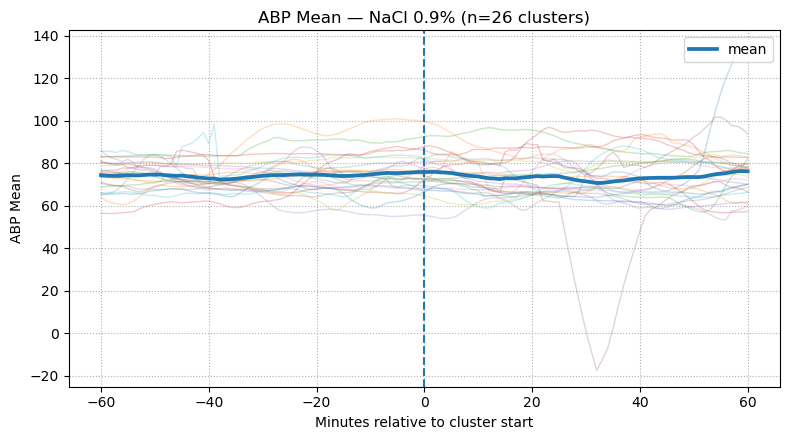

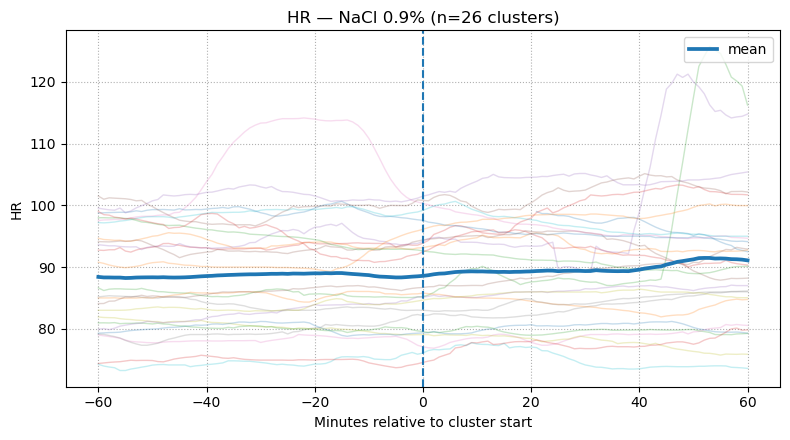

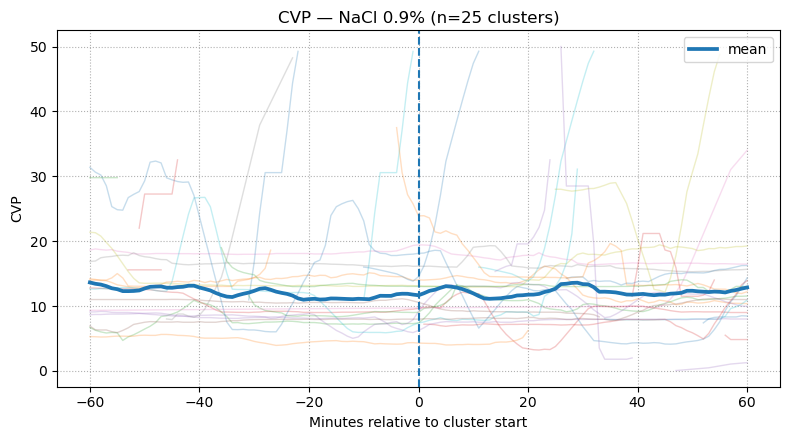

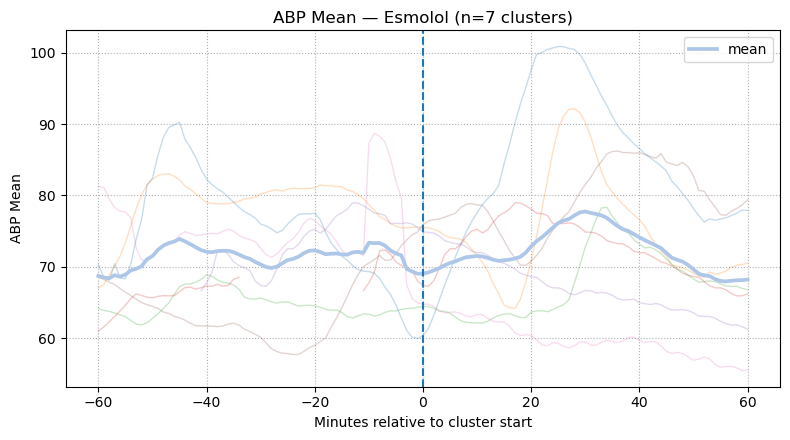

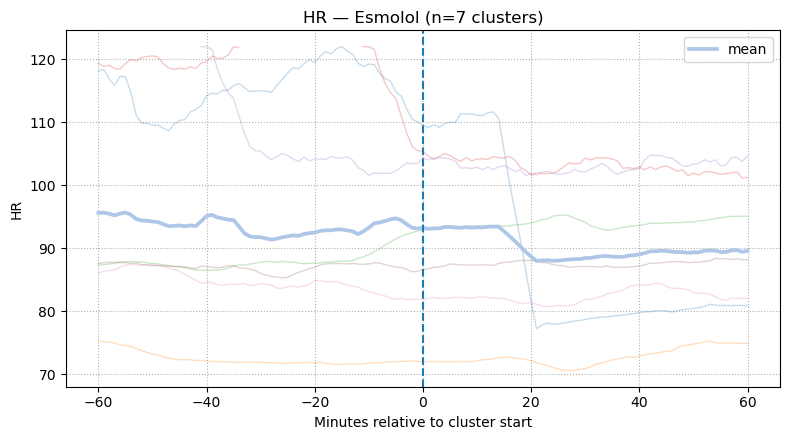

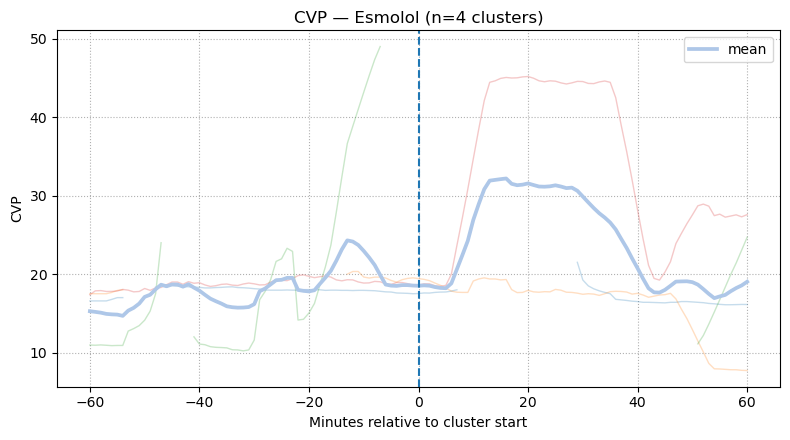

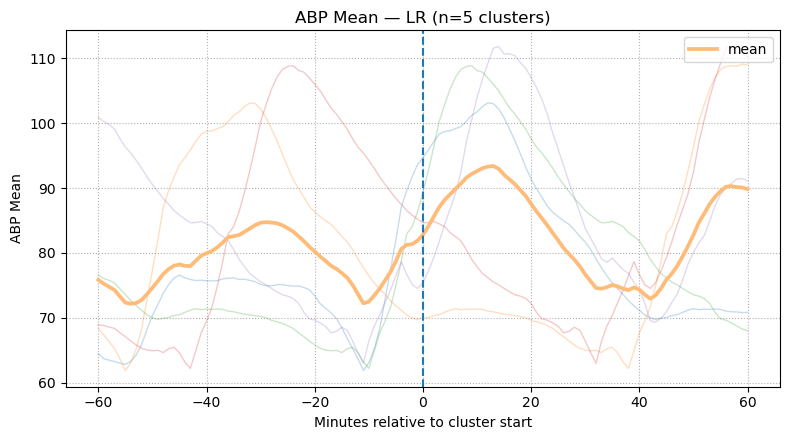

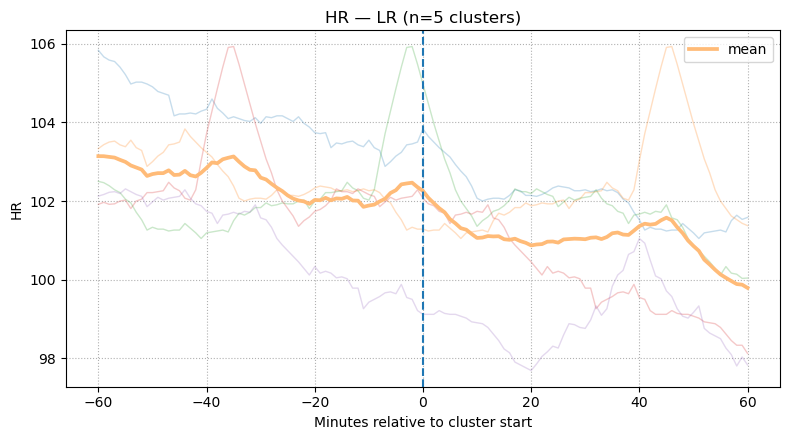

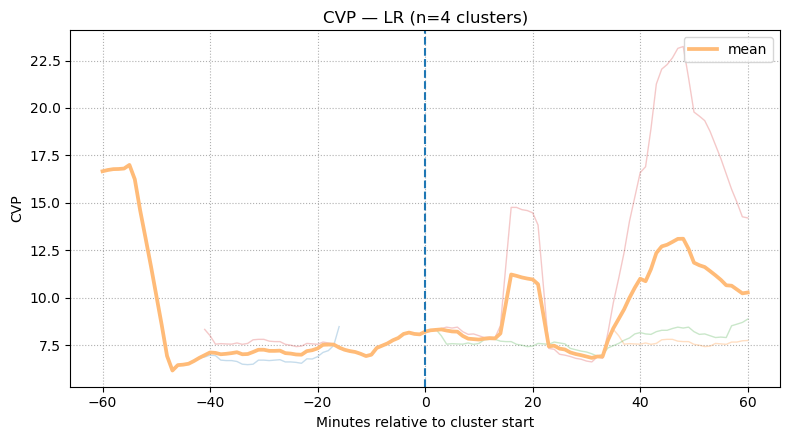

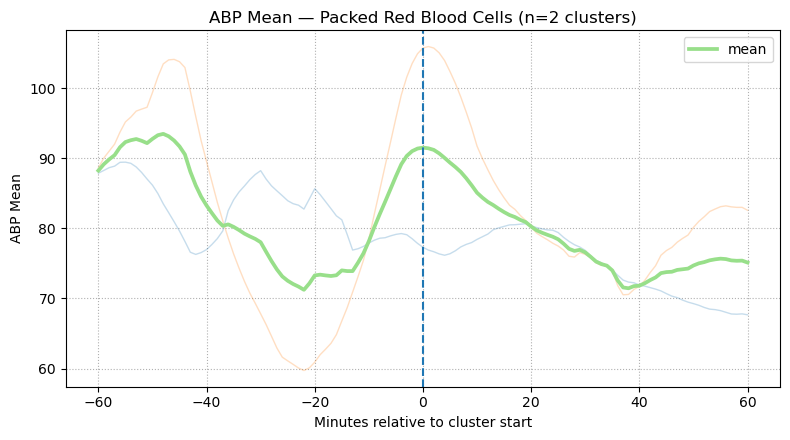

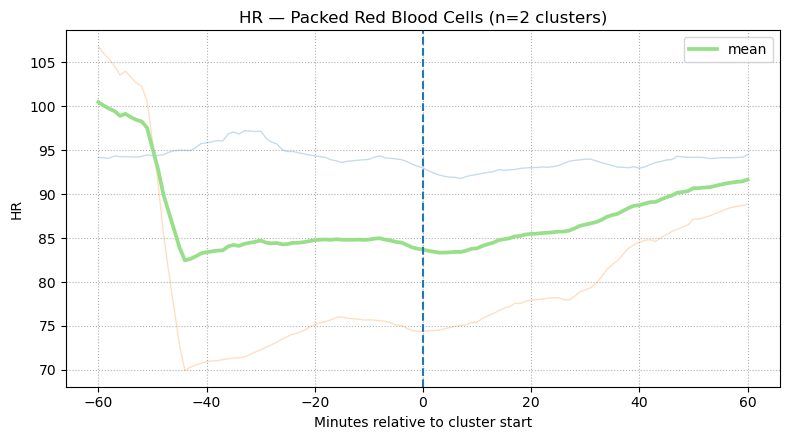

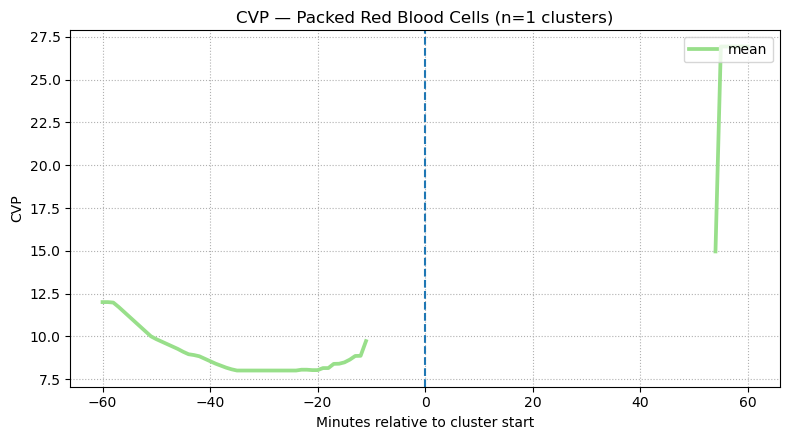

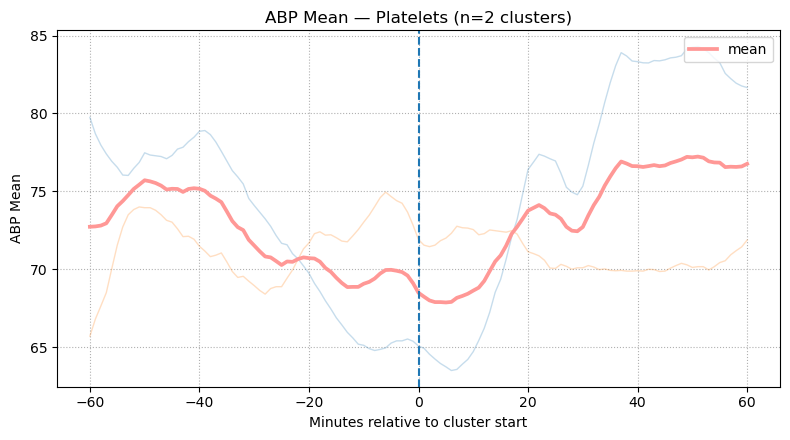

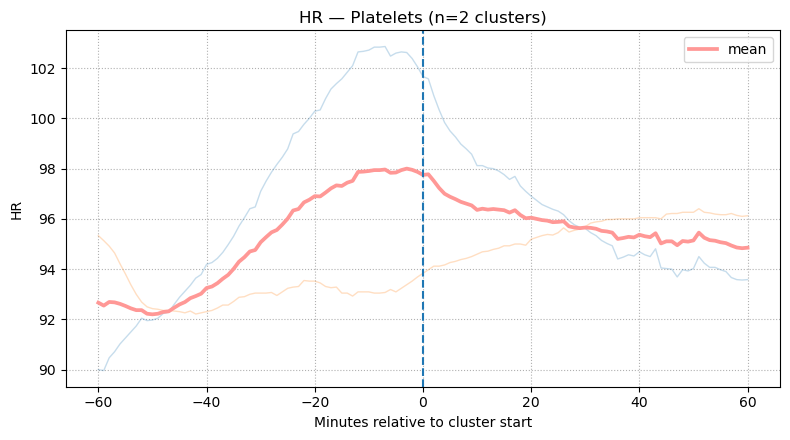

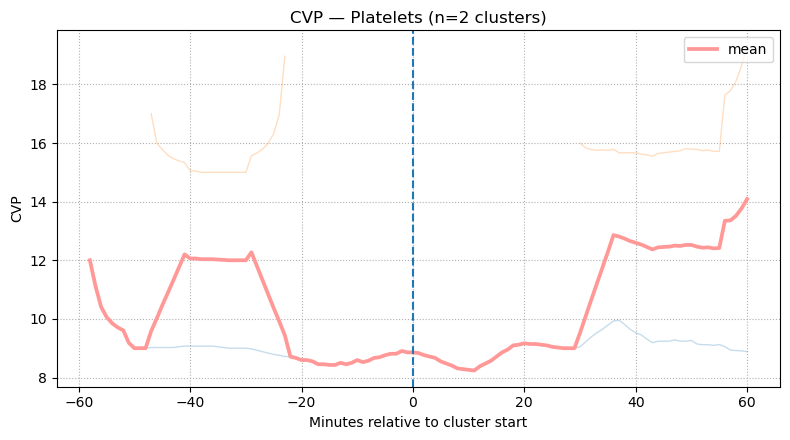

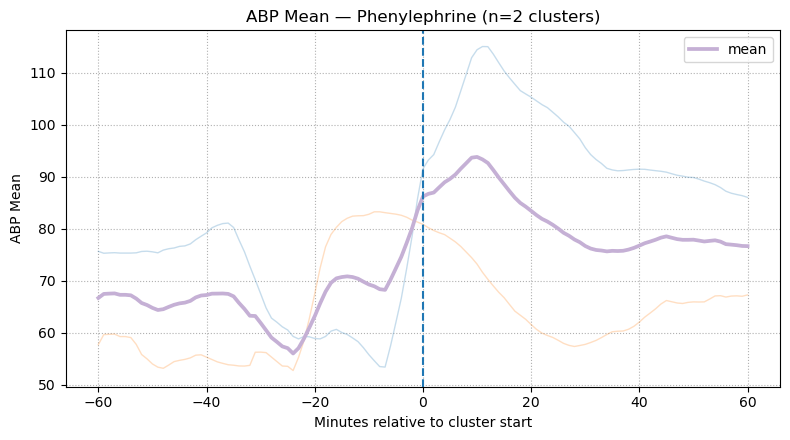

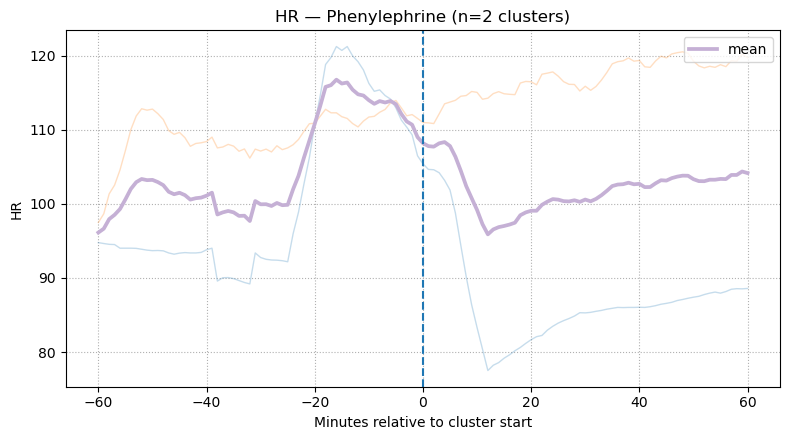

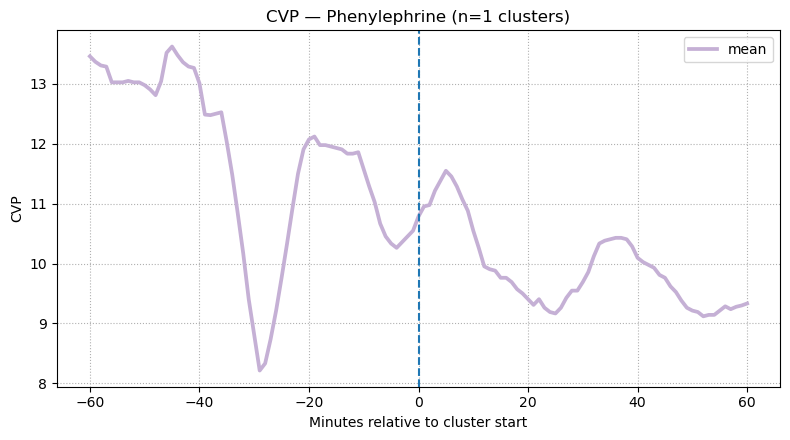

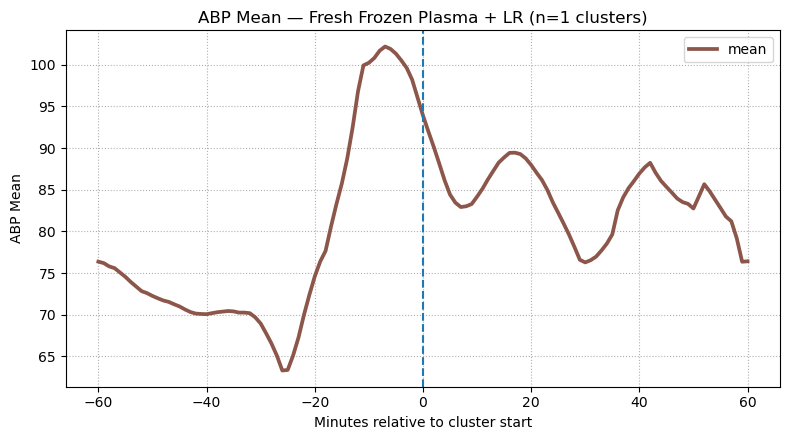

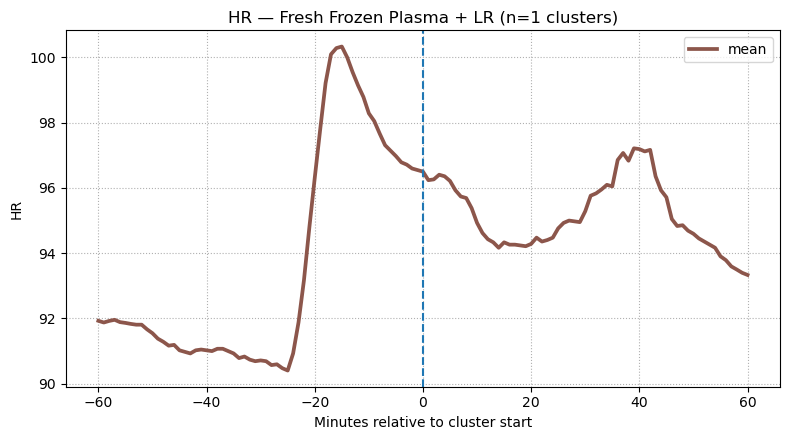

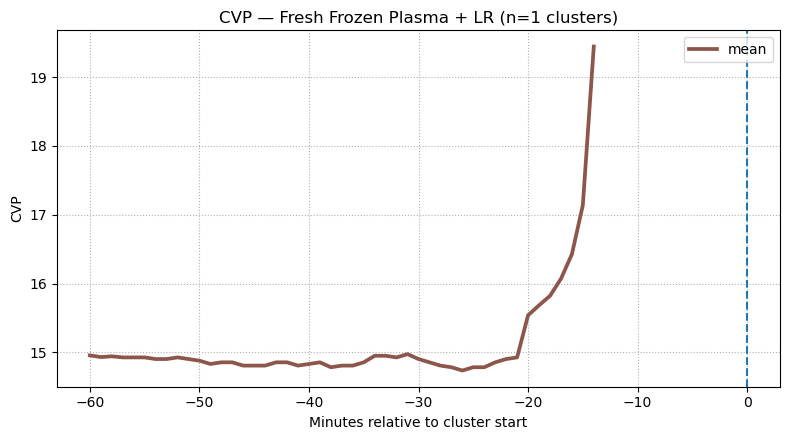

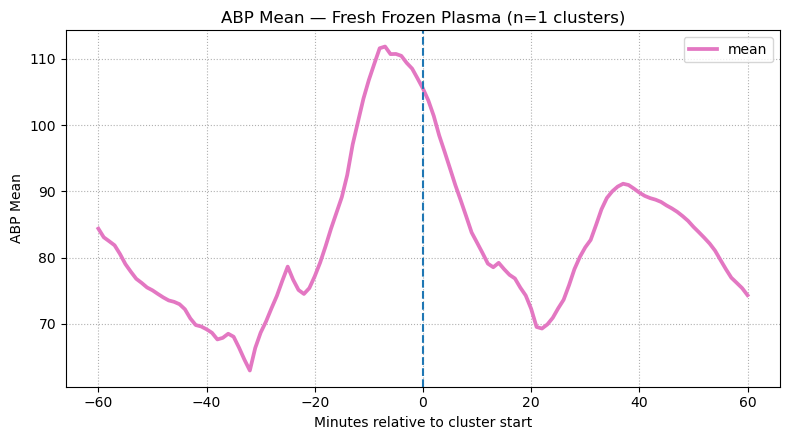

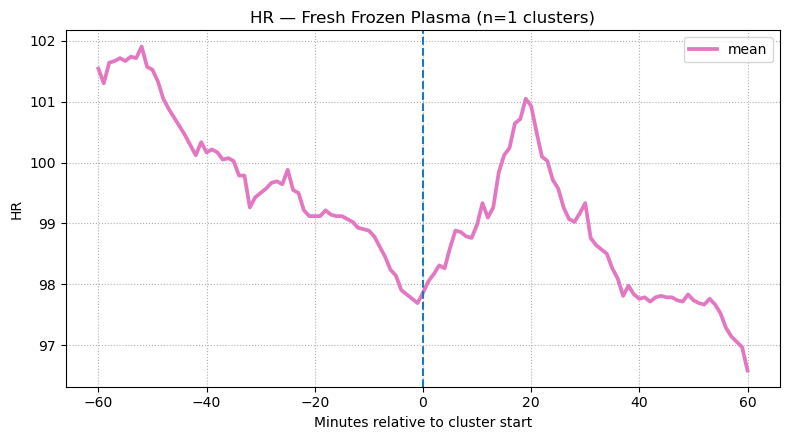

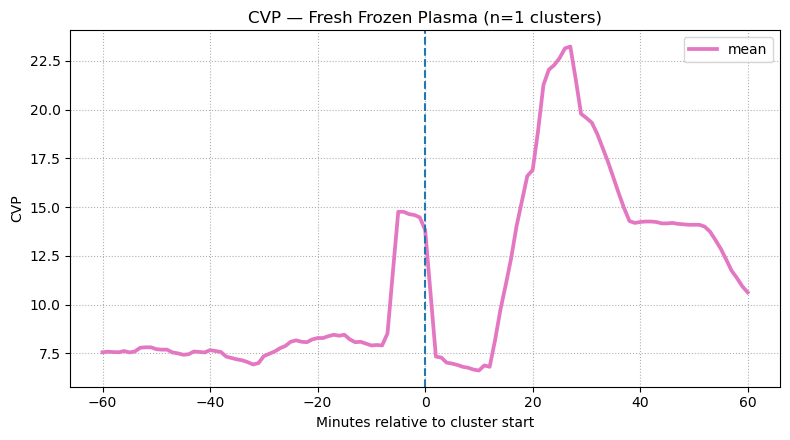

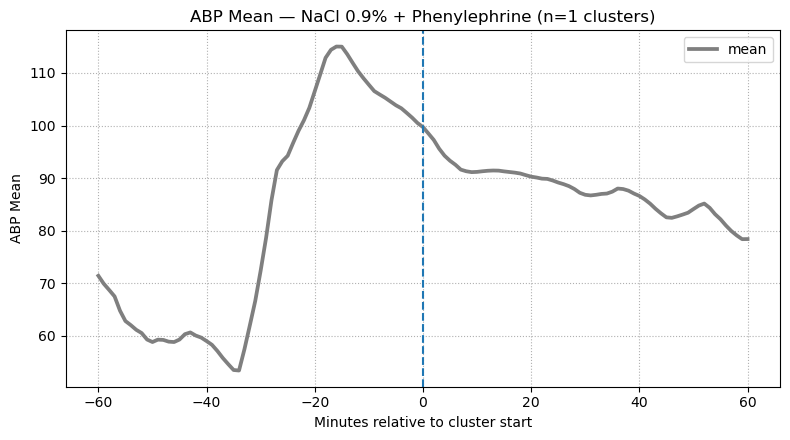

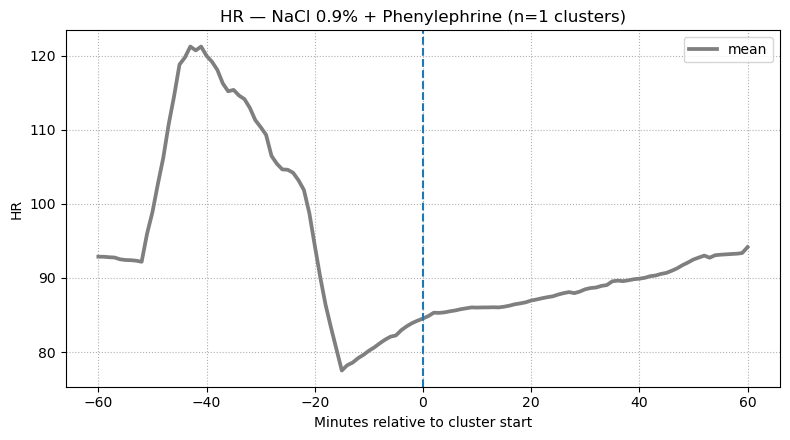

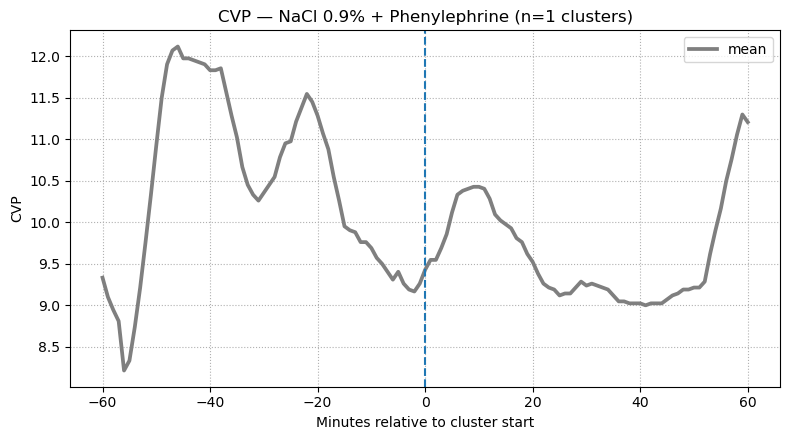

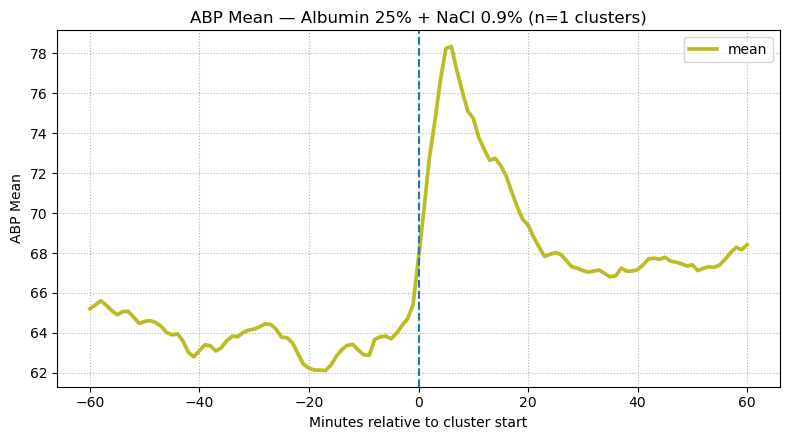

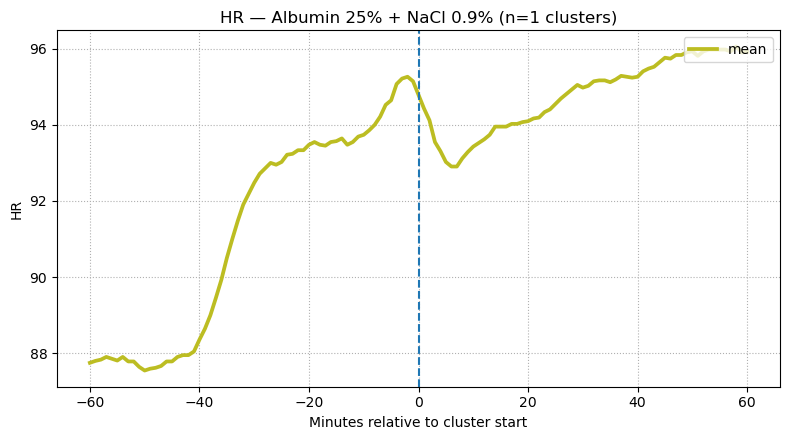

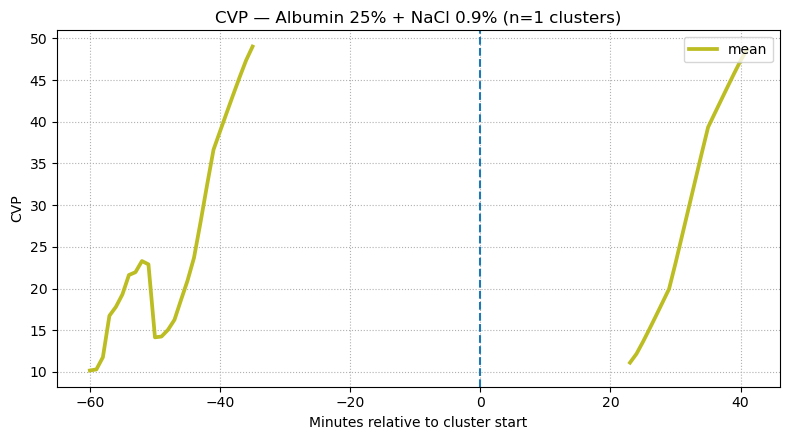

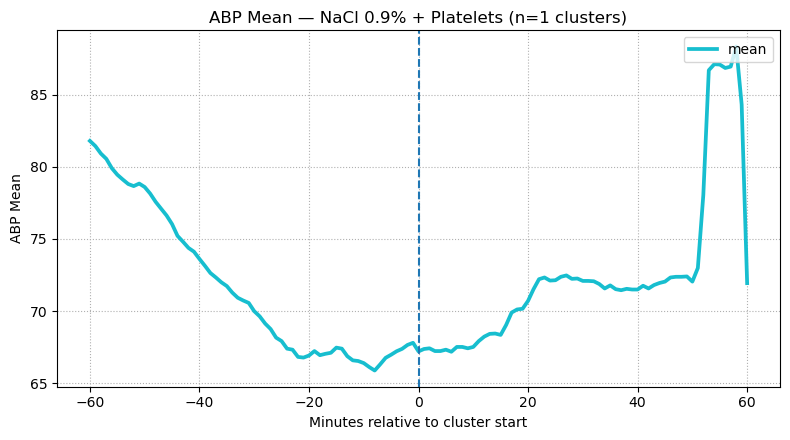

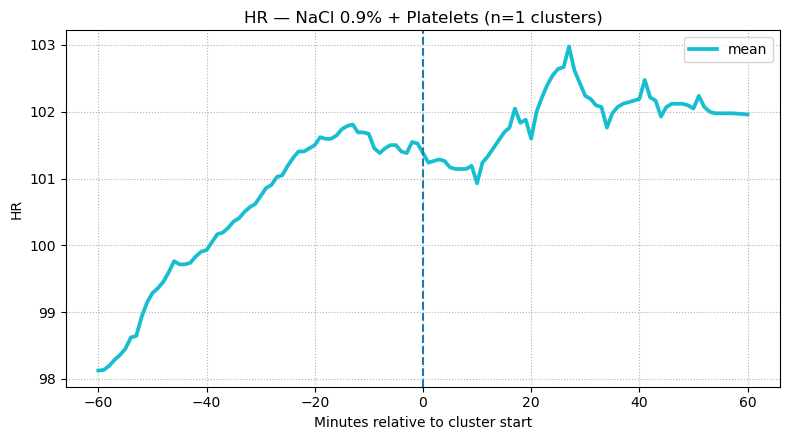

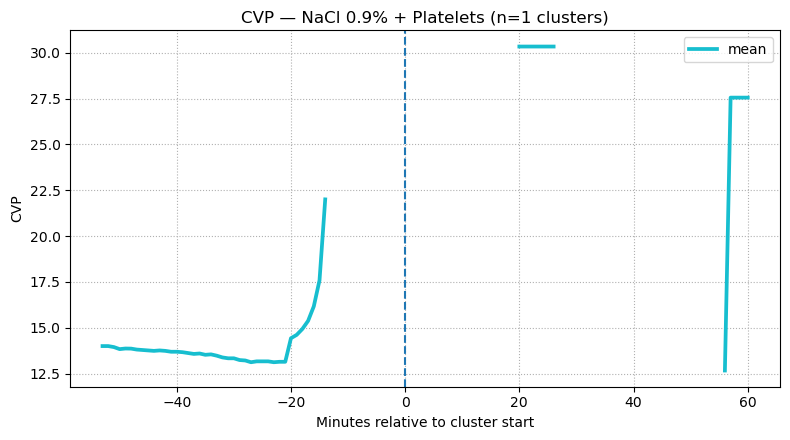

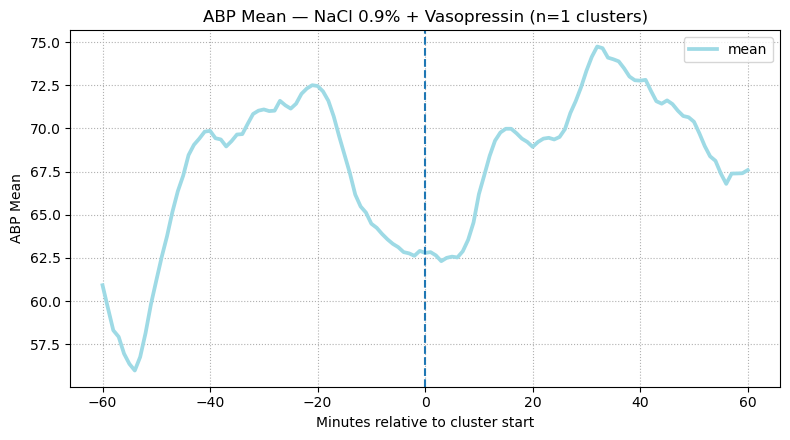

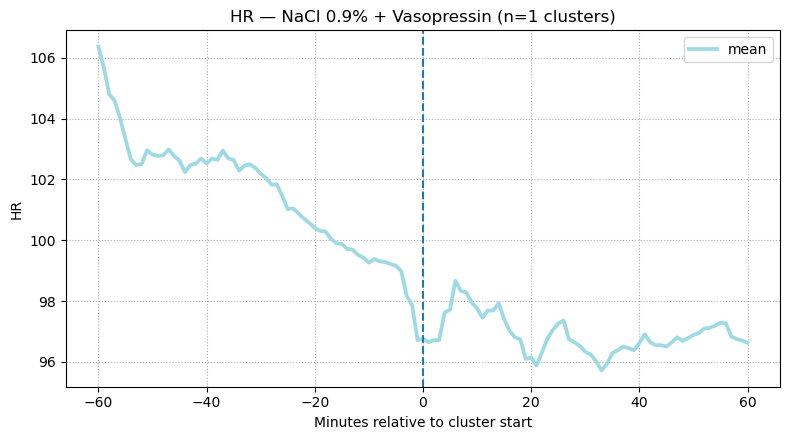

In [166]:
# -------------------- run --------------------
# Configure your hadm_id and (optionally) a cap on number of cluster types
HADM_ID = 101662    # replace as needed
TOP_N_TYPES = 10  # set to an int (e.g., 10) to limit

summary_table = plot_cluster_type_spaghetti(
    res_df=res_sample_waveform_filtered,
    wf_df=wf_df,
    hadm_id=101662,
    signals=("ABP Mean","HR","CVP"),
    minutes_before=60,
    minutes_after=60,
    top_n_types=12,          # or None for all
    resample_rule="1min",
    min_points=10,
    faint_alpha=0.25,
    faint_lw=1.0,
    mean_lw=2.7,
    smoothing_neighbors=3,   # <— 7-point window
    outdir="outputs_cluster_types"
)

In [167]:
def _sanitize(name: str) -> str:
    name = name.strip().replace(" ", "_")
    return re.sub(r"[^A-Za-z0-9_.+-]", "", name)[:120]

def _cluster_type_label(labels: pd.Series) -> str:
    uniq = sorted(set([str(x) for x in labels if pd.notna(x)]), key=str.lower)
    return " + ".join(uniq) if uniq else "UNKNOWN"

def _relative_minute_index(minutes_before:int, minutes_after:int):
    return np.arange(-minutes_before, minutes_after + 1, dtype=int)

def _qc_waveforms(wf: pd.DataFrame, signals=("ABP Mean","HR","CVP")) -> pd.DataFrame:
    wf = wf.copy()
    wf["absolute_timestamp"] = pd.to_datetime(wf["absolute_timestamp"], utc=True, errors="coerce")
    for s in signals:
        if s in wf.columns:
            wf[s] = pd.to_numeric(wf[s], errors="coerce")
    # QC masks & NaN-out-of-range
    if "CVP" in signals and "CVP" in wf.columns:
        wf["CVP_mask"] = 1.0
        bad_cvp = (wf["CVP"] < 0) | (wf["CVP"] > 50)
        wf.loc[bad_cvp, "CVP_mask"] = 0.0
        wf.loc[bad_cvp, "CVP"] = np.nan
    if "ABP Mean" in signals and "ABP Mean" in wf.columns:
        wf["ABP Mean_mask"] = 1.0
        bad_map = (wf["ABP Mean"] > 200)
        wf.loc[bad_map, "ABP Mean_mask"] = 0.0
        wf.loc[bad_map, "ABP Mean"] = np.nan
    if "HR" in signals and "HR" in wf.columns and "HR_mask" not in wf.columns:
        wf["HR_mask"] = 1.0
    return wf

def _smooth_1d_nanaware(arr: np.ndarray, neighbors: int) -> np.ndarray:
    if neighbors <= 0 or arr.size == 0:
        return arr.copy()
    win_len = 2*neighbors + 1
    kernel = np.ones(win_len, dtype=float)
    vals = arr.astype(float)
    valid = np.isfinite(vals).astype(float)
    num = np.convolve(np.nan_to_num(vals, nan=0.0), kernel, mode="same")
    den = np.convolve(valid, kernel, mode="same")
    out = np.divide(num, den, out=np.full_like(num, np.nan), where=den > 0)
    return out

def _smooth_matrix_rows(M: np.ndarray, neighbors: int) -> np.ndarray:
    if neighbors <= 0 or M.size == 0:
        return M
    out = np.empty_like(M, dtype=float)
    for i in range(M.shape[0]):
        out[i, :] = _smooth_1d_nanaware(M[i, :], neighbors)
    return out

def _extract_aligned_windows_for_hadm(
    wf_min_by_hadm: dict,
    hadm_id: int,
    event_times: pd.Series,
    signals=("ABP Mean","HR","CVP"),
    minutes_before=60,
    minutes_after=60,
    min_points=5
):
    """
    Extract aligned windows for a single hadm_id from its resampled wf_min frame.
    Returns dict signal -> list of episode rows (each np.array) aligned to common rel_minutes.
    """
    rel_idx = _relative_minute_index(minutes_before, minutes_after)
    out = {sig: [] for sig in signals}
    if hadm_id not in wf_min_by_hadm:
        return out, rel_idx
    wf_min = wf_min_by_hadm[hadm_id]

    for t0 in event_times.dropna():
        t0 = pd.to_datetime(t0, utc=True, errors="coerce")
        t_start = t0 + pd.Timedelta(minutes=-minutes_before)
        t_end   = t0 + pd.Timedelta(minutes= minutes_after)
        for sig in signals:
            seg = wf_min.loc[t_start:t_end, sig].copy() if sig in wf_min.columns else pd.Series(dtype=float)
            if seg.empty:
                out[sig].append(None)
                continue
            rel = ((seg.index - t0).total_seconds() / 60.0).round().astype(int)
            aligned = pd.Series(seg.values, index=rel).reindex(rel_idx)
            if np.isfinite(aligned.values).sum() >= min_points:
                out[sig].append(aligned.values.astype(float))
            else:
                out[sig].append(None)
    return out, rel_idx

def plot_cluster_type_spaghetti_multi(
    res_df: pd.DataFrame,
    wf_df: pd.DataFrame,
    hadm_ids: list,
    signals=("ABP Mean","HR","CVP"),
    minutes_before=60,
    minutes_after=60,
    top_n_types: int = None,
    resample_rule="1min",
    min_points=10,
    faint_alpha=0.25,
    faint_lw=1.0,
    mean_lw=2.7,
    smoothing_neighbors: int = 0,
    outdir="outputs_cluster_types_multi"
):
    # Filter to requested encounters and clustered triggers
    df = res_df[res_df["hadm_id"].isin(hadm_ids) & res_df["trigger"] & res_df["action_cluster_id"].notna()].copy()
    if df.empty:
        print("No trigger clusters for the requested hadm_ids.")
        return pd.DataFrame()

    df["start_time"] = pd.to_datetime(df["start_time"], utc=True, errors="coerce")

    # Build (hadm_id, action_cluster_id) -> cluster_start and type
    cluster_start = (df.groupby(["hadm_id","action_cluster_id"], as_index=False)["start_time"]
                       .min()
                       .rename(columns={"start_time":"cluster_start"}))
    clabels = (df.groupby(["hadm_id","action_cluster_id"])["item_label"]
                 .apply(_cluster_type_label)
                 .rename("cluster_type")
                 .reset_index())
    meta = cluster_start.merge(clabels, on=["hadm_id","action_cluster_id"], how="left")

    # Global type counts across all hadm_ids
    type_counts = (meta["cluster_type"]
                   .value_counts()
                   .rename_axis("cluster_type")
                   .reset_index(name="n_occurrences"))
    # Optional cap
    if top_n_types is not None and top_n_types > 0:
        keep_types = set(type_counts.head(top_n_types)["cluster_type"])
        meta = meta[meta["cluster_type"].isin(keep_types)]
        type_counts = type_counts.head(top_n_types)

    # QC + resample waveforms per hadm_id
    wf = _qc_waveforms(wf_df, signals=signals)
    wf = wf.dropna(subset=["absolute_timestamp"]).sort_values("absolute_timestamp")
    # Build a dict of resampled frames by hadm_id
    wf_min_by_hadm = {}
    for hid, w in wf.groupby("hadm_id", sort=False):
        wmin = (w.set_index("absolute_timestamp")[list(signals)]
                  .astype(float)
                  .resample(resample_rule).mean())
        wf_min_by_hadm[int(hid)] = wmin

    out_path = Path(outdir); out_path.mkdir(parents=True, exist_ok=True)

    # Color per cluster type (consistent across signals and across all hadm_ids)
    import matplotlib as mpl
    cmap = mpl.cm.get_cmap("tab20", max(3, len(type_counts)))
    color_for_type = {ctype: cmap(i % cmap.N) for i, ctype in enumerate(type_counts["cluster_type"])}

    artifacts = []
    # Iterate cluster types in frequency order (desc)
    for _, row in type_counts.iterrows():
        ctype = row["cluster_type"]
        mean_color = color_for_type[ctype]

        # Collect aligned windows for all occurrences of this type (across hadm_ids)
        # Build episode matrices per signal
        episode_lists = {sig: [] for sig in signals}
        rel_idx_global = None

        for hid, sub in meta.loc[meta["cluster_type"] == ctype].groupby("hadm_id"):
            events = sub["cluster_start"].sort_values()
            per_hadm_data, rel_idx = _extract_aligned_windows_for_hadm(
                wf_min_by_hadm, int(hid), events,
                signals=signals,
                minutes_before=minutes_before, minutes_after=minutes_after,
                min_points=min_points
            )
            rel_idx_global = rel_idx if rel_idx_global is None else rel_idx_global
            for sig in signals:
                episode_lists[sig].extend([row for row in per_hadm_data[sig] if row is not None])

        # Now, for each signal, stack to matrix, optional smoothing, compute mean, and plot
        for sig in signals:
            rows = episode_lists[sig]
            if len(rows) == 0:
                continue
            M = np.vstack(rows)
            if smoothing_neighbors and smoothing_neighbors > 0:
                M = _smooth_matrix_rows(M, smoothing_neighbors)
            mean_vec = np.nanmean(M, axis=0)
            if smoothing_neighbors and smoothing_neighbors > 0:
                mean_vec = _smooth_1d_nanaware(mean_vec, smoothing_neighbors)

            # Plot (single chart per figure)
            plt.figure(figsize=(8, 4.5))
            for r in M:
                plt.plot(rel_idx_global, r, alpha=faint_alpha, linewidth=faint_lw)
            if np.isfinite(mean_vec).any():
                plt.plot(rel_idx_global, mean_vec, linewidth=mean_lw, color=mean_color, label="mean")
            plt.axvline(0, linestyle="--")
            plt.title(f"{sig} — {ctype} (n={M.shape[0]} clusters across {len(hadm_ids)} hadm_ids)")
            plt.xlabel("Minutes relative to cluster start")
            plt.ylabel(sig)
            plt.grid(True, linestyle=":")
            if np.isfinite(mean_vec).any():
                plt.legend(loc="upper right")
            fname = out_path / f"{_sanitize(ctype)}__{_sanitize(sig)}__multi_{len(hadm_ids)}hadm__K{int(smoothing_neighbors)}.png"
            plt.tight_layout(); plt.savefig(fname, dpi=160)
            artifacts.append(str(fname))

    if artifacts:
        print(f"Saved {len(artifacts)} figures to {out_path.resolve()}")
    else:
        print("No figures generated — no qualifying waveform segments.")


In [ ]:
summary_multi = plot_cluster_type_spaghetti_multi(
    res_df=res_sample_waveform_filtered,
    wf_df=wf_df,
    hadm_ids=[100571, 101662, 102914, 107163, ],   # your list here
    signals=("ABP Mean","HR","CVP"),
    minutes_before=60,
    minutes_after=60,
    top_n_types=12,          # or None for all
    resample_rule="1min",
    min_points=10,
    faint_alpha=0.25,
    faint_lw=1.0,
    mean_lw=2.7,
    smoothing_neighbors=3,   # 7-point window
    outdir="outputs_cluster_types_multi"
)

/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_65052/2361883602.py:328: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = mpl.cm.get_cmap(palette_name, max(3, len(clusters)))


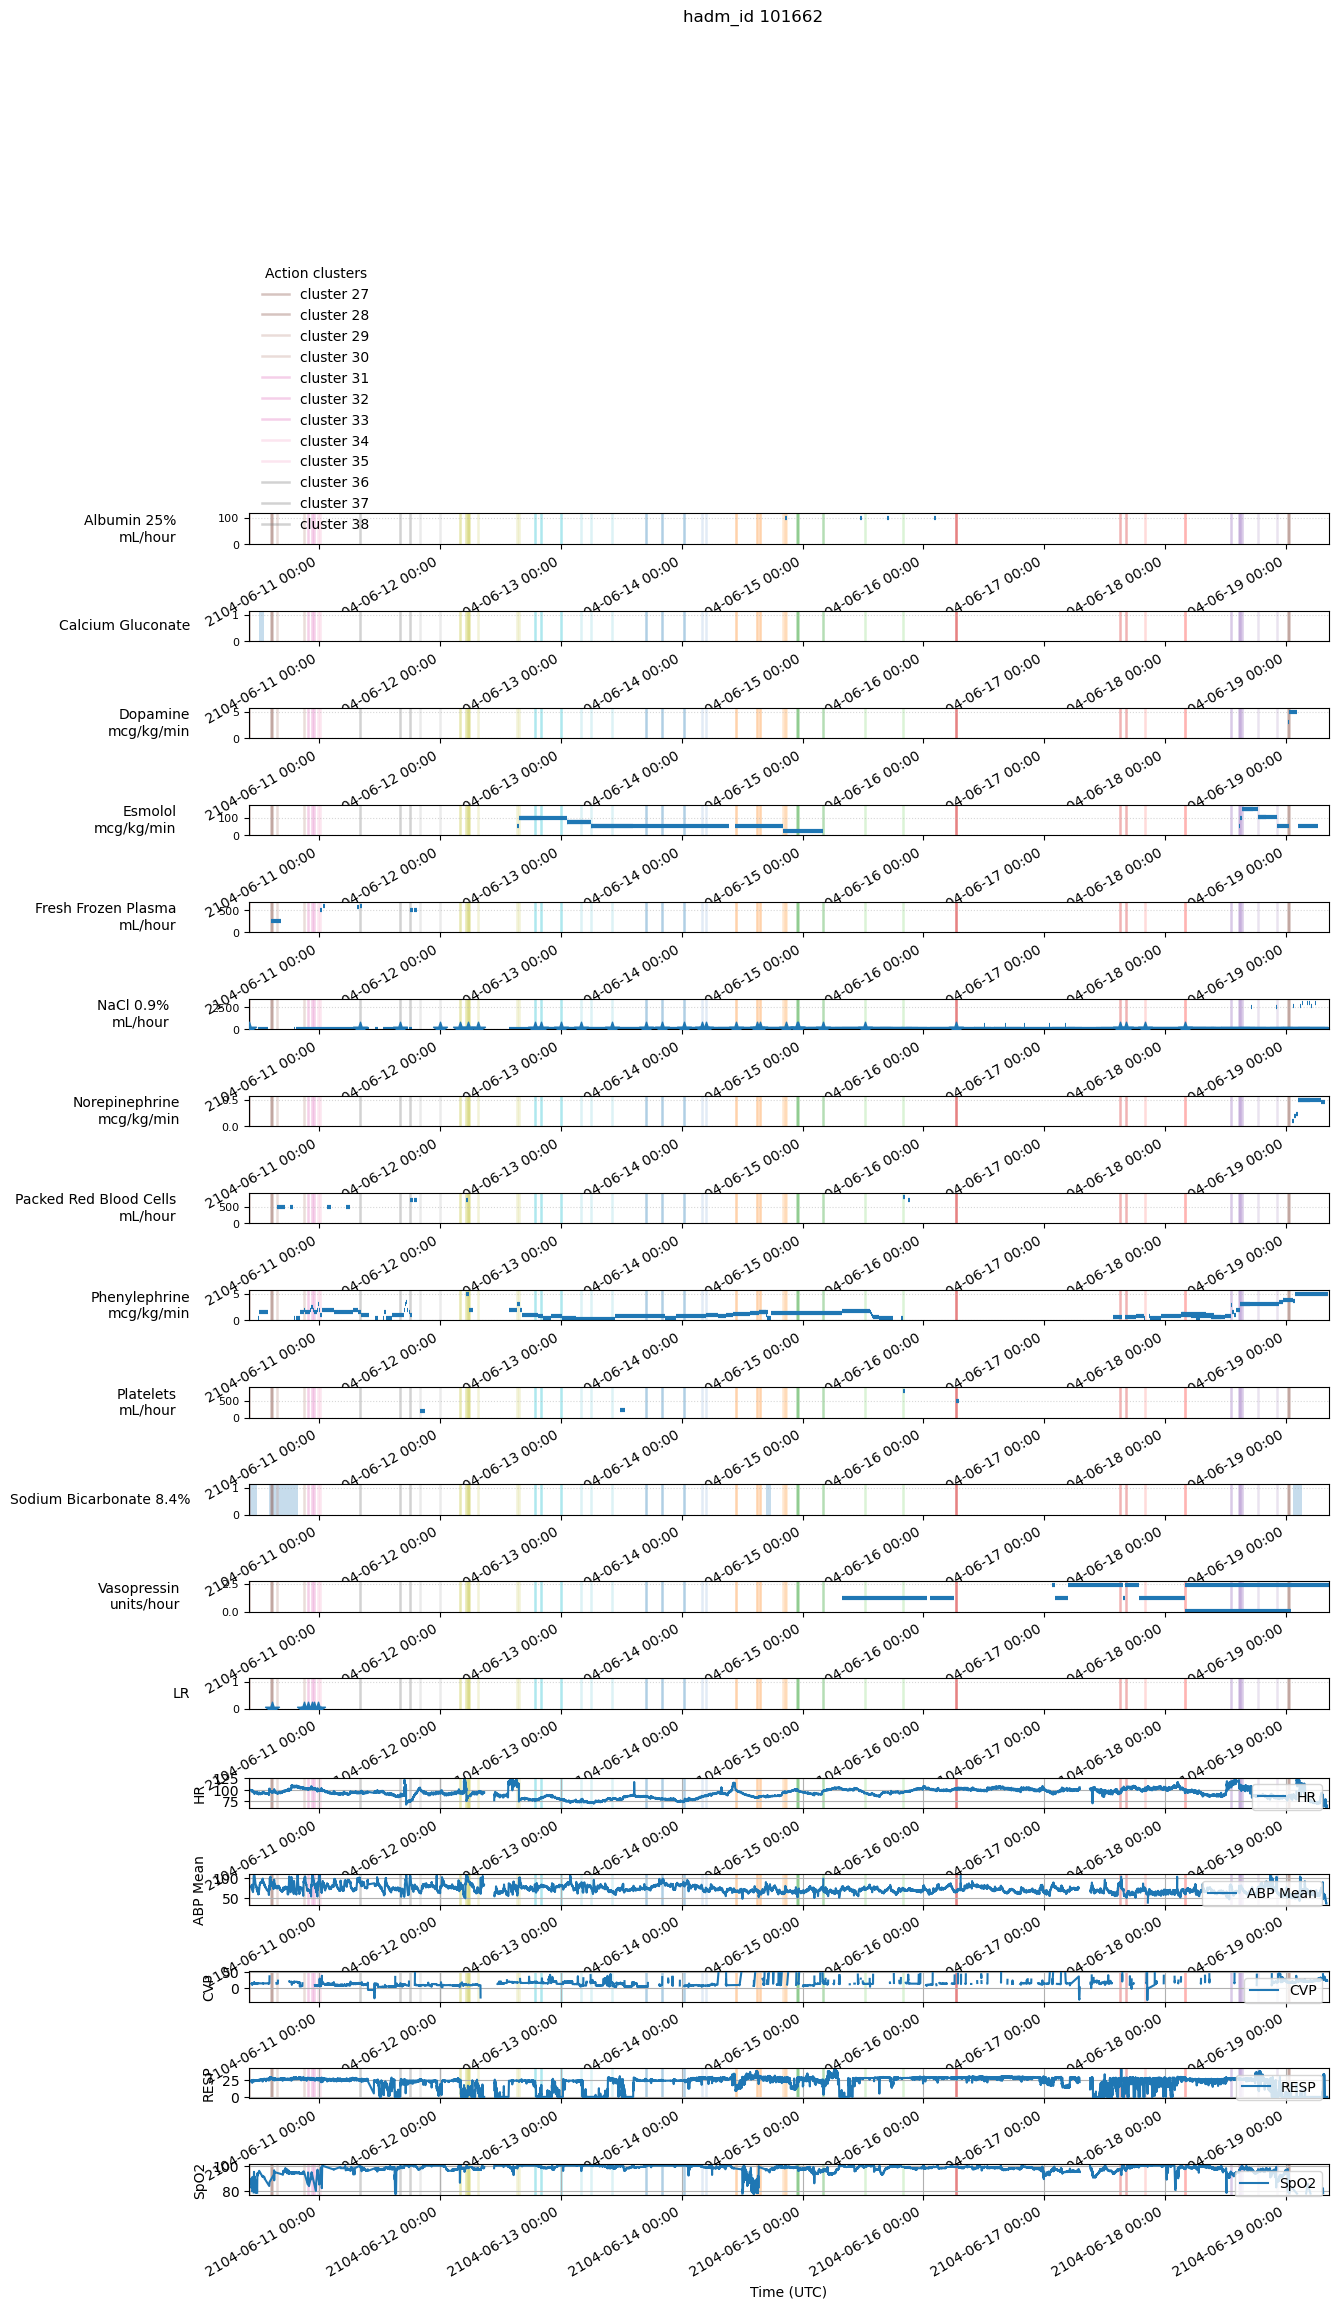

In [156]:
hadm_id = 101662

stack = PanelStack(
    title=f"hadm_id {hadm_id}",
    auto_height_per_axis=8,   # give each axis more room
    max_height=200
)

# Page 1: first 16 items (sorted by class, then A–Z)
(_, page_meta) = stack.add_inputs_timeline_by_label(
    res_sample_waveform_filtered, hadm_id,
    items_per_page=16, page=1,            # <— paginate here
    height_units_per_item=3,              # taller rows
    star_size=110
)

# Waveforms
stack.add_waveforms(
    wf_df,
    signals=['HR','ABP Mean','CVP','RESP','SpO2'],
    neighbors=3,
    height_units_per_signal=3
)

stack.add_action_cluster_lines(
    res_sample_waveform_filtered, hadm_id,
    include_singletons=True,   # set True if you want single-trigger clusters drawn too
    palette_name="tab20",       # change palette if you like
    alpha=0.35,
    linewidth=1.8
)

fig, axes = stack.finalize()
plt.show()


In [60]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from typing import Iterable, Optional, Tuple, Sequence

def plot_hadm_inputs_timeline_by_label(
    inputs_df_labeled: pd.DataFrame,
    hadm_id: int,
    *,
    bolus_labels: Iterable[str] = ("bolus", "drug push"),
    continuous_labels: Iterable[str] = ("continuous iv", "continuous med"),
    class_order: Sequence[str] = ("continuous", "bolus/push", "other"),
    figsize: Optional[Tuple[float, float]] = None,
    star_size: int = 120,
):
    """
    Same rules as before, but:
      • Each subplot corresponds to an item **label** ('item_label')
      • Subplots are ordered by the item's **class** (Continuous → Bolus/Push → Other),
        then alphabetically by label.

    Expects columns from build_inputs_df + 'item_label'.
    """
    df = inputs_df_labeled
    req = ["hadm_id","item_id","item_label","input_name","input_class",
           "start_time","end_time","rate","rate_uom"]
    missing = [c for c in req if c not in df.columns]
    if missing:
        raise ValueError(f"Dataframe missing required columns: {missing}")

    df = df.loc[df["hadm_id"] == hadm_id].copy()
    if df.empty:
        raise ValueError(f"No rows for hadm_id={hadm_id}.")

    # normalize datetimes/rates
    df["start_time"] = pd.to_datetime(df["start_time"], utc=True, errors="coerce")
    df["end_time"]   = pd.to_datetime(df["end_time"],   utc=True, errors="coerce").fillna(df["start_time"])
    df["rate"]       = pd.to_numeric(df["rate"], errors="coerce")

    # class flags
    ic = df["input_class"].astype(str).str.lower()
    iname = df["input_name"].astype(str).str.lower()

    bolus_mask = pd.Series(False, index=df.index)
    for lbl in bolus_labels:
        bolus_mask |= ic.str.contains(lbl, na=False) | iname.str.contains(lbl, na=False)

    continuous_mask = pd.Series(False, index=df.index)
    for lbl in continuous_labels:
        continuous_mask |= ic.str.contains(lbl, na=False) | iname.str.contains(lbl, na=False)

    # assign a canonical class per row
    row_class = np.where(continuous_mask, "continuous",
                 np.where(bolus_mask, "bolus/push", "other"))
    df["row_class"] = row_class

    # assign a single class per label (mode → tie-break: class_order priority)
    priority = {c: i for i, c in enumerate(class_order)}
    def label_class_mode(g):
        counts = g["row_class"].value_counts()
        best = sorted(counts.index.tolist(), key=lambda c: (priority.get(c, 999), -counts[c]))[0]
        return best
    label_class = df.groupby("item_label", sort=False).apply(label_class_mode).rename("label_class")
    df = df.merge(label_class, left_on="item_label", right_index=True, how="left")

    # determine subplot order: by class_order, then alphabetical label
    labels = (
        df[["item_label","label_class"]].drop_duplicates()
          .sort_values(["label_class","item_label"],
                       key=lambda s: s.map(priority) if s.name=="label_class" else s.str.lower())
          .loc[:, "item_label"]
          .tolist()
    )

    n_items = len(labels)
    figsize = (12, max(2.5, 1.6 * n_items)) if figsize is None else figsize
    fig, axes = plt.subplots(n_items, 1, sharex=True, figsize=figsize, constrained_layout=True)
    if n_items == 1:
        axes = [axes]

    x_min = min(df["start_time"].dropna().min(), df["end_time"].dropna().min())
    x_max = max(df["start_time"].dropna().max(), df["end_time"].dropna().max())

    def unit_label(g):
        u = g["rate_uom"].dropna().astype(str).unique()
        return u[0] if len(u) == 1 else ""

    for ax, label in zip(axes, labels):
        g = df[df["item_label"] == label].copy()
        g_bolus = g[g["row_class"] == "bolus/push"]
        g_cont  = g[g["row_class"] == "continuous"]
        g_other = g[g["row_class"] == "other"]

        # robust y max
        all_rates = pd.concat([g_bolus["rate"], g_cont["rate"], g_other["rate"]], axis=0)
        ymax = float(all_rates.max()) if all_rates.notna().any() else 1.0
        if not np.isfinite(ymax) or ymax <= 0: ymax = 1.0
        ax.set_ylim(0, ymax * 1.15)

        # draw continuous
        for _, r in g_cont.iterrows():
            if pd.notna(r["rate"]):
                ax.hlines(y=r["rate"], xmin=r["start_time"], xmax=r["end_time"], linewidth=3)
            else:
                ax.axvspan(r["start_time"], r["end_time"], alpha=0.25)

        # draw bolus/push
        if not g_bolus.empty:
            y_star = g_bolus["rate"].fillna(0.0)
            ax.scatter(g_bolus["start_time"], y_star, marker="*", s=star_size, zorder=3)

        # draw others
        for _, r in g_other.iterrows():
            if r["start_time"] == r["end_time"]:
                ax.scatter([r["start_time"]], [r["rate"] if pd.notna(r["rate"]) else 0.0],
                           marker="*", s=star_size/1.5, zorder=3)
            else:
                if pd.notna(r["rate"]):
                    ax.hlines(y=r["rate"], xmin=r["start_time"], xmax=r["end_time"], linewidth=2, linestyle="--")
                else:
                    ax.axvspan(r["start_time"], r["end_time"], alpha=0.15, hatch="///")

        u = unit_label(g)
        ax.set_ylabel(f"{label}\n{u}".strip(), rotation=0, ha="right", va="center", labelpad=30)
        ax.grid(True, axis="y", linestyle=":", alpha=0.5)

    # full datetime on x-axis
    axes[-1].set_xlim(x_min, x_max)
    axes[-1].set_xlabel("Time (UTC)")
    locator = mdates.AutoDateLocator()
    formatter = mdates.DateFormatter('%Y-%m-%d %H:%M', tz=mdates.UTC)
    for ax in axes:
        ax.xaxis.set_major_locator(locator)
        ax.xaxis.set_major_formatter(formatter)
        for t in ax.get_xticklabels():
            t.set_rotation(30); t.set_ha("right")

    # legend
    axes[0].plot([], [], linewidth=3, label="Continuous (rate)")
    axes[0].fill_between([], [], [], alpha=0.25, label="Continuous (no rate)")
    axes[0].scatter([], [], marker="*", s=star_size, label="Bolus / Push")
    axes[0].legend(loc="upper right", frameon=False)

    fig.suptitle(f"Inputs Timeline — hadm_id {hadm_id} (sorted by class)", y=1.02, fontsize=12)
    return fig, axes

/var/folders/53/d8br5nln6vq67q925j2wx6kc0000gn/T/ipykernel_65052/205411438.py:63: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  label_class = df.groupby("item_label", sort=False).apply(label_class_mode).rename("label_class")


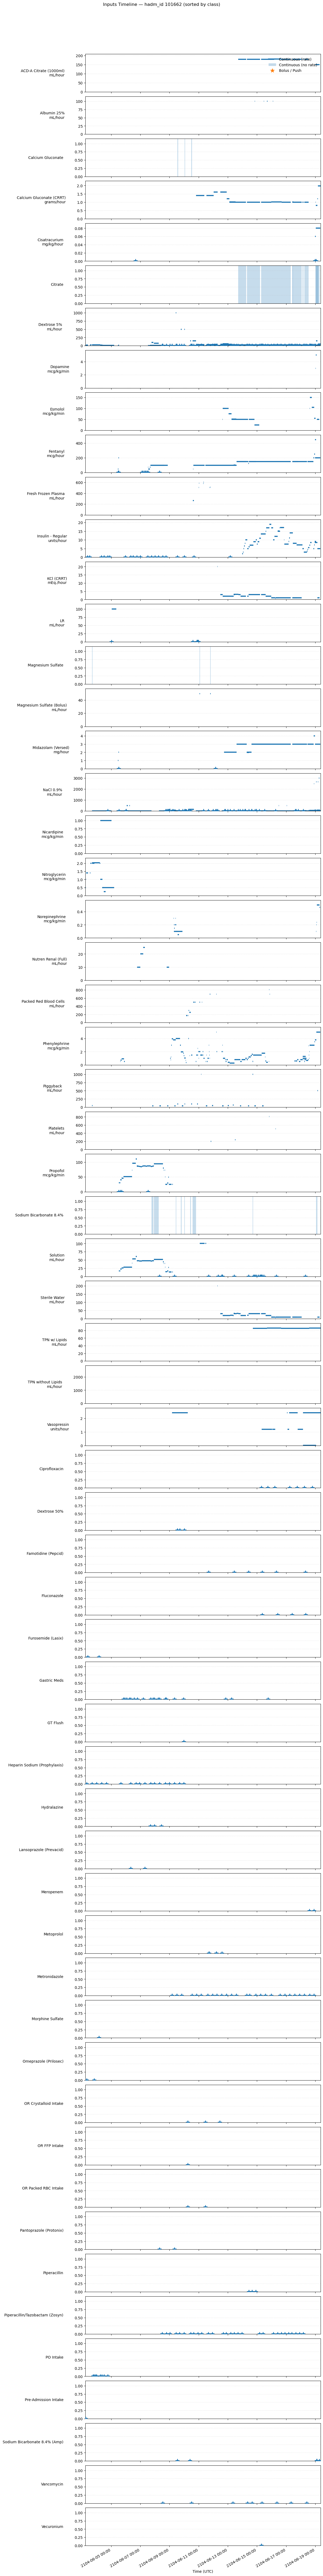

In [36]:
fig, axes = plot_hadm_inputs_timeline_by_label(input_events_filtered, hadm_id=101662)
plt.show()

In [ ]:
import os
import pandas as pd

def load_and_process_csv_for_hadm_ids(file_path, hadm_ids, chunk_size=1000000, usecols=None, source=None):
    """
    Loads a CSV file in chunks, filtering for rows with hadm_id in hadm_ids,
    and applies source-specific processing:
      - For 'chartevents': renames 'valuenum' to 'value'
      - For 'inputevents': renames 'amount' -> 'value' and 'starttime' -> 'charttime'
      - For 'labevents': renames 'valuenum' to 'value'
      - For 'emar': renames 'medication' -> 'name', 'event_txt' -> 'value', 'emar_id' -> 'itemid'
      - For 'micro_events': renames 'micro_specimen_id' -> 'itemid', 'test_name' -> 'name', 'comments' -> 'value'
    Drops rows with NA in 'value' and converts 'charttime' (or starttime) to datetime.

    If the pickle already exists in the temp_dfs folder, load and return it.
    """
    # Ensure the directory exists
    temp_dir = '../temp_dfs'
    os.makedirs(temp_dir, exist_ok=True)

    # Define a unique pickle filename based on the CSV file name and source.
    base_name = os.path.basename(file_path).replace('.csv', '')
    pickle_file = os.path.join(temp_dir, f"{base_name}_{source}.pkl")

    # If the pickle file exists, load and return it.
    if os.path.exists(pickle_file):
        print(f"Loading existing pickle file: {pickle_file}")
        return pd.read_pickle(pickle_file)

    chunks = []
    for i, chunk in enumerate(pd.read_csv(file_path, chunksize=chunk_size, usecols=usecols)):
        # Filter the chunk for the given hadm_ids.
        filtered_chunk = chunk[chunk['hadm_id'].isin(hadm_ids)]
        
        # Apply source-specific renaming:
        if source == 'chartevents':
            filtered_chunk = filtered_chunk.rename(columns={'valuenum': 'value'})
        elif source == 'inputevents':
            filtered_chunk = filtered_chunk.rename(columns={'amount': 'value', 'starttime': 'charttime'})
        elif source == 'labevents':
            filtered_chunk = filtered_chunk.rename(columns={'valuenum': 'value'})
        elif source == 'emar':
            filtered_chunk = filtered_chunk.rename(columns={'medication': 'name', 'event_txt': 'value', 'emar_id': 'itemid'})
        elif source =='micro_events':
            filtered_chunk = filtered_chunk.rename(columns={'micro_specimen_id': 'itemid', 'test_name': 'name', 'comments': 'value'})
        
        # Drop rows with missing 'value'
        filtered_chunk = filtered_chunk.dropna(subset=['value'])
        
        # Convert 'charttime' to datetime if it exists in the columns.
        if 'charttime' in filtered_chunk.columns:
            filtered_chunk['charttime'] = pd.to_datetime(filtered_chunk['charttime'], errors='coerce')
        
        chunks.append(filtered_chunk)
        print(f"Chunk {i} processed, shape after filter: {filtered_chunk.shape}")
    
    # Concatenate all chunks
    result = pd.concat(chunks, ignore_index=True)
    
    # Save the resulting DataFrame as a pickle file.
    print(f"Saving result to pickle file: {pickle_file}")
    result.to_pickle(pickle_file)
    
    return result

# Example usage:
hadm_ids = set(merged_with_disch_df['hadm_id'])

print('processing chartevents')
# Load physiologic event data
chartevents_filtered = load_and_process_csv_for_hadm_ids(
    chartevents_path, hadm_ids, usecols=physio_cols_to_keep['chartevents'], source='chartevents'
)
print('processing outputevents')
outputevents_filtered = load_and_process_csv_for_hadm_ids(
    outputevents_path, hadm_ids, usecols=physio_cols_to_keep['outputevents'], source='outputevents'
)
print('processing labevents')
labevents_filtered = load_and_process_csv_for_hadm_ids(
    labevents_path, hadm_ids, usecols=physio_cols_to_keep['labevents'], source='labevents'
)

,time_seconds,HR,PULSE,ABP,ABP Sys,ABP Dias,ABP Mean,CVP,ART,ART Sys,...,SpO2,PVC Rate per Minute,Rhythm Status,Ectopic Status,Ectopic Count,record_name,record_start_time,record_end_time,hadm_id,t0_timestamps
0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,p099008-2173-02-19-22-05n,2173-02-19 22:05:30,2173-02-23 20:11:52,100571,[2173-02-20T10:48:36.000000]
1,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,p099008-2173-02-19-22-05n,2173-02-19 22:05:30,2173-02-23 20:11:52,100571,[2173-02-20T10:48:36.000000]
2,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,p099008-2173-02-19-22-05n,2173-02-19 22:05:30,2173-02-23 20:11:52,100571,[2173-02-20T10:48:36.000000]
3,30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,p099008-2173-02-19-22-05n,2173-02-19 22:05:30,2173-02-23 20:11:52,100571,[2173-02-20T10:48:36.000000]
4,40,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,p099008-2173-02-19-22-05n,2173-02-19 22:05:30,2173-02-23 20:11:52,100571,[2173-02-20T10:48:36.000000]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
33873,338730,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,p099008-2173-02-19-22-05n,2173-02-19 22:05:30,2173-02-23 20:11:52,100571,[2173-02-20T10:48:36.000000]
33874,338740,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,p099008-2173-02-19-22-05n,2173-02-19 22:05:30,2173-02-23 20:11:52,100571,[2173-02-20T10:48:36.000000]
33875,338750,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,p099008-2173-02-19-22-05n,2173-02-19 22:05:30,2173-02-23 20:11:52,100571,[2173-02-20T10:48:36.000000]
33876,338760,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,p099008-2173-02-19-22-05n,2173-02-19 22:05:30,2173-02-23 20:11:52,100571,[2173-02-20T10:48:36.000000]


In [38]:
full_waveform_data_dict[100571].columns

Index(['time_seconds', 'HR', 'PULSE', 'ABP', 'ABP Sys', 'ABP Dias', 'ABP Mean',
       'CVP', 'ART', 'ART Sys', 'ART Dias', 'ART Mean', 'NBP', 'NBP Sys',
       'NBP Dias', 'NBP Mean', 'RESP', 'SpO2', 'PVC Rate per Minute',
       'Rhythm Status', 'Ectopic Status', 'Ectopic Count', 'record_name',
       'record_start_time', 'record_end_time', 'hadm_id', 't0_timestamps'],
      dtype='object')

In [ ]:

# ----------------------------
# Config
# ----------------------------
signals = ['HR', 'ABP Mean', 'CVP', 'RESP', 'SpO2']
neighbors = 3  # average of current +/- this many neighbors (3 => 7-point window)

# Convenience
time = full_waveform_data['time_seconds']
t0 = pd.to_datetime(full_waveform_data['t0_timestamps'].iloc[0])

# Work on a copy
df = full_waveform_data[signals].copy()

# ----------------------------
# 1) Clean: CVP threshold, others by std-from-median
# ----------------------------
for sig in signals:
    s = df[sig].astype(float).copy()

    if sig == 'CVP':
        # CVP-specific filter
        s[s > 50] = np.nan
    else:
        # Outlier removal for the rest: > 3 * std from median
        med = np.nanmedian(s)
        sd = np.nanstd(s, ddof=1)
        if np.isfinite(sd) and sd > 0:
            mask_out = np.abs(s - med) > (3 * sd)
            s[mask_out] = np.nan
        # if sd == 0 or non-finite, do nothing

    df[sig] = s

# ----------------------------
# 2) Manual centered moving average (ignoring NaNs)
#    Uses convolution on values and a validity mask
# ----------------------------
win_len = 2 * neighbors + 1
kernel = np.ones(win_len, dtype=float)

smoothed = pd.DataFrame(index=df.index, columns=signals, dtype=float)

for sig in signals:
    vals = df[sig].to_numpy(dtype=float)

    # numerator: sum over window (treat NaNs as 0)
    num = np.convolve(np.nan_to_num(vals, nan=0.0), kernel, mode='same')

    # denominator: count of non-NaN in window
    valid = np.isfinite(vals).astype(float)
    den = np.convolve(valid, kernel, mode='same')

    out = num / den
    out[den == 0] = np.nan  # keep gaps where no valid samples in the window

    smoothed[sig] = out

# ----------------------------
# 3) Plot
# ----------------------------
fig, axes = plt.subplots(len(signals), 1, figsize=(12, 12), sharex=True)

for i, sig in enumerate(signals):
    ax = axes[i]

    # Plot only if there is some non-NaN data after smoothing
    if np.isfinite(smoothed[sig]).any():
        ax.plot(time, smoothed[sig], label=sig, linewidth=1.5)

    # Vertical line at t0 only if time is datetime-like
    if pd.api.types.is_datetime64_any_dtype(time):
        ax.axvline(x=t0, color='red', linestyle='--', label='t0')

    ax.set_ylabel(sig)
    ax.grid(True)
    ax.legend(loc='upper right')

axes[-1].set_xlabel('Time')
if pd.api.types.is_datetime64_any_dtype(time):
    axes[-1].xaxis.set_major_formatter(mdates.DateFormatter('%H:%M:%S'))

plt.tight_layout()
plt.show()